In [ ]:
"""
@author: Zongyi Li
This file is the Fourier Neural Operator for 1D problem such as the (time-independent) Burgers equation discussed in Section 5.1 in the [paper](https://arxiv.org/pdf/2010.08895.pdf).
"""
# del F
import os
import pickle
from timeit import default_timer

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from Adam import Adam
from utilities3 import *


torch.manual_seed(0)
np.random.seed(0)


def createFolder(directory):
    try:
        if not os.path.exists(directory):
            os.makedirs(directory)
    except OSError:
        print("Error: Creating directory. " + directory)


################################################################
#  1d fourier layer
################################################################
class SpectralConv1d(nn.Module):
    def __init__(self, in_channels, out_channels, modes1):
        super(SpectralConv1d, self).__init__()

        """
        1D Fourier layer. It does FFT, linear transform, and Inverse FFT.    
        """

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes1 = (
            modes1  # Number of Fourier modes to multiply, at most floor(N/2) + 1
        )

        self.scale = 1 / (in_channels * out_channels)
        self.weights1 = nn.Parameter(
            self.scale
            * torch.rand(in_channels, out_channels, self.modes1, 2, dtype=torch.float)
        )

    # Complex multiplication
    def compl_mul1d(self, input, weights):
        # (batch, in_channel, x ), (in_channel, out_channel, x) -> (batch, out_channel, x)

        weights = torch.complex(weights[:, :, :, 0], weights[:, :, :, 1])
        return torch.einsum("bix,iox->box", input, weights)

    def forward(self, x):
        batchsize = x.shape[0]
        # Compute Fourier coeffcients up to factor of e^(- something constant)
        x_ft = torch.fft.rfft(x)

        # Multiply relevant Fourier modes
        out_ft = torch.zeros(
            batchsize,
            self.out_channels,
            x.size(-1) // 2 + 1,
            device=x.device,
            dtype=torch.cfloat,
        )
        out_ft[:, :, : self.modes1] = self.compl_mul1d(
            x_ft[:, :, : self.modes1], self.weights1
        )

        # Return to physical space
        x = torch.fft.irfft(out_ft, n=x.size(-1))
        return x


class FNO1d_1(nn.Module):
    def __init__(self, modes, width, depth, kernz):
        super(FNO1d_1, self).__init__()

        """
        The overall network. It contains 4 layers of the Fourier layer.
        1. Lift the input to the desire channel dimension by self.fc0 .
        2. 4 layers of the integral operators u' = (W + K)(u).
            W defined by self.w; K defined by self.conv .
        3. Project from the channel space to the output space by self.fc1 and self.fc2 .
        
        input: the solution of the initial condition and location (a(x), x)
        input shape: (batchsize, x=s, c=2)
        output: the solution of a later timestep
        output shape: (batchsize, x=s, c=1)
        """

        self.modes1 = modes
        self.width = width
        self.depth = depth
        self.kernelsize = kernz
        self.padding = 4  # pad the domain if input is non-periodic
        self.fc0 = nn.Linear(5, self.width, bias=False)  # input channel is 2: (a(x), x)

        self.fouriers = nn.ModuleList(
            [
                SpectralConv1d(self.width, self.width, self.modes1)
                for i in range(self.depth)
            ]
        )
        self.convs = nn.ModuleList(
            [
                nn.Conv1d(
                    self.width,
                    self.width,
                    self.kernelsize,
                    padding=int(self.kernelsize / 2),
                )
                for i in range(self.depth)
            ]
        )

        self.relu = nn.GELU()

        self.fc1 = nn.Linear(self.width, 128, bias=False)
        self.fc2 = nn.Linear(128, 2)

    def forward(self, x):
        grid = self.get_grid(x.shape, x.device)
        x = torch.cat((x, grid), dim=-1)
        # print(x.shape)
        x = self.fc0(x)
        # print(x.shape)
        x = x.permute(0, 2, 1)
        # print(x.shape)
        # x = F.pad(x, [self.padding,self.padding], mode='replicate') # pad the domain if input is non-periodic

        x0 = x

        for i in range(self.depth):
            x1 = self.fouriers[i](x)
            x2 = self.convs[i](x)

            x = self.relu(x1 + x2)
            # x0 = x
            # x = self.relu(x1)

        # x = x[..., self.padding:-self.padding] # pad the domain if input is non-periodic
        x = x.permute(0, 2, 1)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)

        return x

    def get_grid(self, shape, device):
        batchsize, size_x = shape[0], shape[1]
        gridx = torch.tensor(np.linspace(0, 1, size_x), dtype=torch.float)
        gridx = gridx.reshape(1, size_x, 1).repeat([batchsize, 1, 1])
        return gridx.to(device)


################################################################
#  configurations
################################################################
ntrain = 1000
ntest = 100

sub = 2**3  # subsampling rate
h = 2**13 // sub  # total grid size divided by the subsampling rate
s = h

batch_size = 100
learning_rate = 0.001

epochs = 10
step_size = 50
gamma = 0.5

modes = 1  # 16
width = 64


In [ ]:
################################################################
# read data
################################################################

# Data is of the shape (number of samples, grid size)


for datas in ["TRAIN_SHALLOW_1000_0.1_256"]:
    with open("./data/" + datas + ".pickle", "rb") as fr:
        train_raw_set_loaded = pickle.load(fr)

    x_train = torch.tensor(
        train_raw_set_loaded["train_X"][0][0].T, dtype=torch.float
    ).unsqueeze(-1)[
        0 : (torch.tensor(train_raw_set_loaded["train_X"][0][0].T).shape[0] // 128)
        * 128
    ]
    # deltat = torch.tensor(train_raw_set_loaded['train_X'][0][1][0:(torch.tensor(train_raw_set_loaded['train_X'][0][0]).shape[0] // 1280)*1280])

    # for i in range(len(train_raw_set_loaded['train_X'])):

    for i in range(1, 1000):
        x_train = torch.cat(
            (
                x_train,
                (
                    torch.tensor(
                        train_raw_set_loaded["train_X"][i][0].T, dtype=torch.float
                    ).unsqueeze(-1)[
                        0 : (
                            torch.tensor(train_raw_set_loaded["train_X"][i][0].T).shape[
                                0
                            ]
                            // 128
                        )
                        * 128
                    ]
                ),
            )
        )
        # deltat = torch.cat((deltat, torch.tensor(train_raw_set_loaded['train_X'][i][1][0:(torch.tensor(train_raw_set_loaded['train_X'][i][0]).shape[0] // 100)*100])))
        # x_train.append((torch.tensor(train_raw_set_loaded['train_X'][i][0], dtype=torch.float).unsqueeze(-1), torch.tensor(train_raw_set_loaded['train_X'][i][1], dtype=torch.float)))

    x_train2 = torch.tensor(
        train_raw_set_loaded["train_X"][0][1].T, dtype=torch.float
    ).unsqueeze(-1)[
        0 : (torch.tensor(train_raw_set_loaded["train_X"][0][1].T).shape[0] // 128)
        * 128
    ]
    # deltat = torch.tensor(train_raw_set_loaded['train_X'][0][1][0:(torch.tensor(train_raw_set_loaded['train_X'][0][0]).shape[0] // 1280)*1280])

    # for i in range(len(train_raw_set_loaded['train_X'])):

    for i in range(1, 1000):
        x_train2 = torch.cat(
            (
                x_train2,
                (
                    torch.tensor(
                        train_raw_set_loaded["train_X"][i][1].T, dtype=torch.float
                    ).unsqueeze(-1)[
                        0 : (
                            torch.tensor(train_raw_set_loaded["train_X"][i][1].T).shape[
                                0
                            ]
                            // 128
                        )
                        * 128
                    ]
                ),
            )
        )
        # deltat = torch.cat((deltat, torch.tensor(train_raw_set_loaded['train_X'][i][1][0:(torch.tensor(train_raw_set_loaded['train_X'][i][0]).shape[0] // 100)*100])))
        # x_train.append((torch.tensor(train_raw_set_loaded['train_X'][i][0], dtype=torch.float).unsqueeze(-1), torch.tensor(train_raw_set_loaded['train_X'][i][1], dtype=torch.float)))


In [ ]:
batch_size = 2560
train_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(torch.cat((x_train, x_train2), dim=2)),
    batch_size=batch_size,
    shuffle=False,
)

In [ ]:
N_in = 0

length = 256
batch_size = 10

batch_indexes = torch.range(N_in, length - 2)

for i in range(1, batch_size):
    batch_indexes = torch.cat(
        (batch_indexes, torch.range(length * i + N_in, length * (i + 1) - 2))
    )

batch_indexes = batch_indexes.to(device).int()

C:\Users\Public\Documents\ESTsoft\CreatorTemp/ipykernel_36604/677603303.py:6: UserWarning: torch.range is deprecated and will be removed in a future release because its behavior is inconsistent with Python's range builtin. Instead, use torch.arange, which produces values in [start, end).
  batch_indexes = torch.range(N_in,length-2)
C:\Users\Public\Documents\ESTsoft\CreatorTemp/ipykernel_36604/677603303.py:10: UserWarning: torch.range is deprecated and will be removed in a future release because its behavior is inconsistent with Python's range builtin. Instead, use torch.arange, which produces values in [start, end).
  batch_indexes = torch.cat((batch_indexes, torch.range(length*i+N_in, length*(i+1)-2)))


In [6]:
x_train.shape

torch.Size([256000, 256, 1])

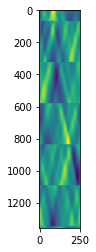

In [ ]:
plt.imshow(x_train[12 + 1200 : 1280 + 1290])

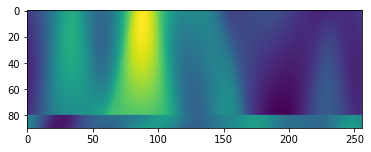

In [7]:
plt.imshow(x_train[1200:1290])

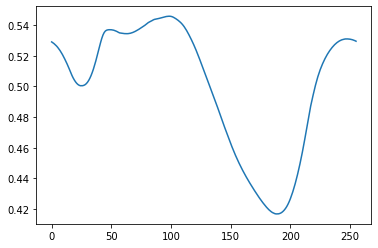

In [8]:
plt.plot(np.roll(x_train[200], 128))

In [ ]:
plt.imshow(x_test[0][:600, :, 0])

NameError: name 'x_test' is not defined

In [ ]:
for datas in ["TEST_SHALLOW_10_0.1_256"]:
    with open("./data/" + datas + ".pickle", "rb") as fr:
        train_raw_set_loaded = pickle.load(fr)

    x_test = []

    for i in range(len(train_raw_set_loaded["train_X"])):
        x_test.append(
            torch.cat(
                (
                    torch.tensor(
                        train_raw_set_loaded["train_X"][i][0], dtype=torch.float
                    ).T.unsqueeze(-1),
                    torch.tensor(
                        train_raw_set_loaded["train_X"][i][1], dtype=torch.float
                    ).T.unsqueeze(-1),
                ),
                dim=2,
            )
        )


for datas in ["TEST2"]:
    with open("./data/" + datas + ".pickle", "rb") as fr:
        train_raw_set_loaded = pickle.load(fr)

    x_test2 = []

    for i in range(len(train_raw_set_loaded["train_X"])):
        x_test2.append(
            (
                torch.tensor(
                    train_raw_set_loaded["train_X"][i][0], dtype=torch.float
                ).unsqueeze(-1),
                torch.tensor(train_raw_set_loaded["train_X"][i][1], dtype=torch.float),
            )
        )


In [33]:
x_test[0].shape

torch.Size([2561, 256, 2])

In [ ]:
re = 3

model = FNO1d_1(5, 64, 1, 1).cuda()

print(count_params(model))
lambd = 100

################################################################
# training and evaluation
################################################################
optimizer = Adam(model.parameters(), lr=learning_rate, weight_decay=re * 1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=step_size, gamma=gamma)

myloss = LpLoss(size_average=False)
myloss2 = LpLoss(size_average=False)
for ep in range(1000):
    model.train()
    t1 = default_timer()
    train_mse = 0
    train_l2 = 0
    train_l2_2 = 0

    aaa = 0
    for x in train_loader:
        # print(aaa)
        aaa += 1

        l2 = 0
        x = x[0]
        optimizer.zero_grad()

        f0 = model(torch.cat((x.cuda(), torch.roll(x.cuda(), -1, dims=1)), dim=2))
        f1 = model(torch.cat((torch.roll(x.cuda(), 1, dims=1), x.cuda()), dim=2))

        l2_tm = lambd * myloss(
            (-(0.1) * (f0 - f1))[batch_indexes],
            (
                torch.roll(x.cuda(), -1, dims=0)[batch_indexes]
                - x.cuda()[batch_indexes]
            ).detach(),
        )
        # l2_tm_roll = lambd*myloss(torch.roll((-(0.1)*(f0-f1))[:-1],128,dims=1), torch.roll((torch.roll(x.cuda(), -1, dims=0)[:-1]-x.cuda()[:-1]),128,dims=1).detach())

        F = model(torch.cat((x.cuda(), x.cuda()), dim=2))

        train_l2_tm = l2_tm.item() / (lambd * len(train_loader) * x.cuda().shape[0])
        FF = torch.cat(
            (
                x[:, :, 1].unsqueeze(-1),
                x[:, :, 1].unsqueeze(-1) ** 2 / x[:, :, 0].unsqueeze(-1)
                + 4.9 * x[:, :, 0].unsqueeze(-1) ** 2,
            ),
            dim=2,
        ).cuda()
        l2_F = myloss(F, FF.detach())  # Burgers
        # l2_F_roll = myloss(torch.roll(F,128,dims=1), torch.roll(FF,128,dims=1).detach()) #Burgers
        # l2 += myloss(F, x[0].cuda()) #advection
        l2 = l2_tm + l2_F
        l2.backward()  # use the l2 relative loss

        optimizer.step()

        train_l2_F = l2_F.item() / (len(train_loader) * x.cuda().shape[0])

    scheduler.step()
    model.eval()

    print(ep, train_l2_tm, train_l2_F)

    t2 = default_timer()

53890
0 0.0007624870300292969 0.0013318299055099488
1 0.0006196359252929688 0.0003060283958911896
2 0.0006046490478515625 0.00015300360321998595
3 0.0005946239089965821 9.552220255136489e-05
4 0.0005912406539916993 9.041029214859009e-05
5 0.0005905432891845703 0.00010621467232704162
6 0.000585850830078125 7.055941969156266e-05
7 0.0005837897109985351 5.797737091779709e-05
8 0.0005829956436157227 5.74096143245697e-05
9 0.0005829578781127929 6.66014701128006e-05
10 0.0005833715057373046 7.7161505818367e-05
11 0.0005799750137329101 6.330166757106781e-05
12 0.0005775483703613281 6.544095277786254e-05
13 0.0005769337463378906 6.78098201751709e-05
14 0.000576981201171875 7.532583922147751e-05
15 0.0005759397125244141 7.836007326841354e-05
16 0.0005774124908447265 8.973261713981629e-05
17 0.0005784381103515625 9.232731163501739e-05
18 0.0005787018966674804 9.796376526355744e-05
19 0.0005753804397583007 9.002837538719178e-05
20 0.0005760453796386719 9.089437127113343e-05
21 0.00057457969665527

In [177]:
f0.shape

torch.Size([256, 256, 2])

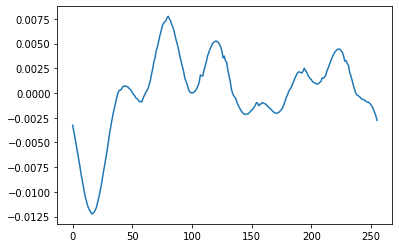

In [ ]:
plt.plot((f1 - f0).detach().cpu()[10, :, 0])

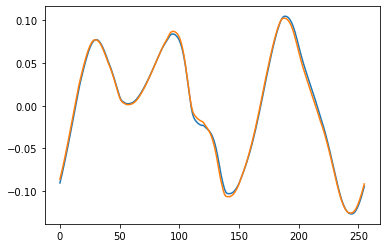

In [ ]:
plt.plot(f1.detach().cpu()[200, :, 0])
plt.plot(FF.detach().cpu()[200, :, 0])

In [ ]:
NN = 0
# x0 = x[0].unsqueeze(0).cuda()
x0 = x_test[NN][0].unsqueeze(0).cuda()
# x0 = x0[0].unsqueeze(0).cuda()
f1 = model(torch.cat((torch.roll(x0.cuda(), 1, dims=1), x0.cuda()), dim=2))
f0 = model(torch.cat((x0.cuda(), torch.roll(x0.cuda(), -1, dims=1)), dim=2))


xx2 = [x0]
T = 0
for i in range(2500):
    T += t1
    x0 = x0 - 0.1 * (f0 - f1)
    f1 = model(torch.cat((torch.roll(x0.cuda(), 1, dims=1), x0.cuda()), dim=2))
    f0 = model(torch.cat((x0.cuda(), torch.roll(x0.cuda(), -1, dims=1)), dim=2))
    if i % 1 == 0:
        xx2.append(x0)

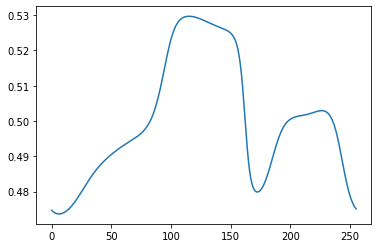

In [ ]:
plt.plot(x0[0, :, 0].detach().cpu())

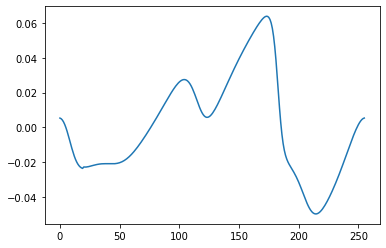

In [ ]:
# plt.plot((f1-f0).detach()[0,:,0].cpu())
plt.plot(np.roll(f1.detach()[0, :, 0].cpu(), 20))

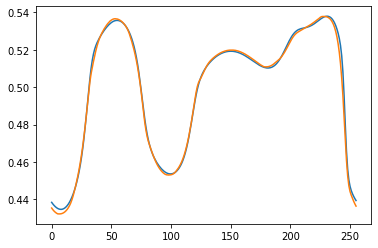

In [ ]:
M = 256 * 2

plt.plot(xx2[M].squeeze()[:, 0].detach().cpu())
# plt.plot(x[M,:,0])
# plt.plot(xx2[0].squeeze()[:,0].detach().cpu())
# plt.plot(x[0,:,0])
plt.plot(x_test[NN][M, :, 0])

In [ ]:
M = 49000

torch.norm(xx2[M].detach().cpu()[0] - x_test[0][0][M].detach().cpu()) / torch.norm(
    x_test[0][0][M].detach().cpu()
)

IndexError: list index out of range

In [ ]:
plt.figure(figsize=(8, 8))
plt.plot(xx2[M].detach().cpu()[0])
# plt.plot(x_test[0][0][M].detach().cpu(), 'r--')
plt.savefig("2111.png")

IndexError: list index out of range

<Figure size 576x576 with 0 Axes>

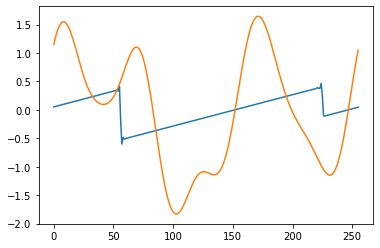

In [19]:
plt.plot(x0.detach().cpu()[0])
plt.plot(x_test[N][0][0].detach().cpu())

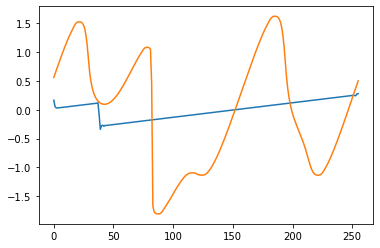

In [36]:
plt.plot(x0.detach().cpu()[0])
plt.plot(x_test[N][0][900].detach().cpu())

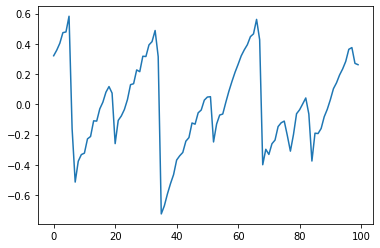

In [241]:
plt.plot(x0.detach().cpu()[0])

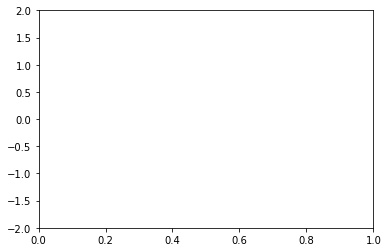

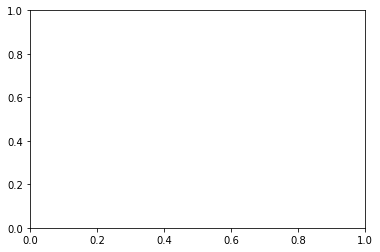

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.animation import FuncAnimation


fig, ax = plt.subplots()
ax.set_xlim(0, 1)
ax.set_ylim(-2.0, 2.0)

x, y = [], []
(line,) = plt.plot([], [])
fig, axes = plt.subplots(nrows=1, ncols=1)


def update(frame):
    x = np.linspace(0, 1, 256)
    y = xx[frame].detach().cpu()[0]
    z = x_test[0][0][frame * 100]

    axes.clear()
    axes.plot(x, y)
    axes.plot(x, z)


ani = FuncAnimation(fig, update, frames=range(145), interval=1)
plt.show()

In [ ]:
ani.save("test_Burgers_256.gif", writer="imagemagick", fps=100)

In [53]:
256 % 128

0

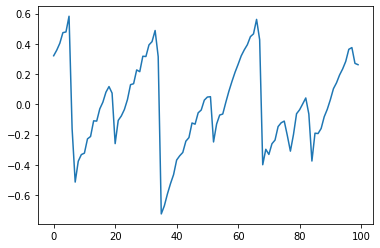

In [247]:
plt.plot(x0.squeeze().detach().cpu())

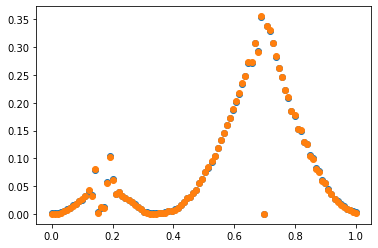

In [ ]:
plt.scatter(
    np.linspace(0, 1, 100),
    model(torch.cat((x0.cuda(), x0.cuda()), dim=2)).squeeze().detach().cpu(),
)
plt.scatter(np.linspace(0, 1, 100), (0.5 * (x0.cuda()) ** 2).detach().cpu()[0])


In [ ]:
model(torch.cat((x0.cuda(), x0.cuda()), dim=2)).squeeze().detach().cpu()

tensor([ 2.3599e-03,  2.0380e-03,  2.2675e-03,  3.5042e-03,  5.4631e-03,
         8.9894e-03,  1.1046e-02,  1.5411e-02,  1.7673e-02,  2.3879e-02,
         2.5822e-02,  3.2104e-02,  4.1202e-02,  3.4487e-02,  7.9154e-02,
         3.2509e-03,  1.1409e-02,  1.1949e-02,  5.7164e-02,  1.0455e-01,
         6.2658e-02,  3.5608e-02,  4.0232e-02,  3.2717e-02,  2.9405e-02,
         2.5438e-02,  2.2035e-02,  1.7065e-02,  1.1741e-02,  8.7820e-03,
         4.2232e-03,  2.6683e-03,  1.5169e-03,  1.8271e-03,  2.0912e-03,
         2.2059e-03,  2.3952e-03,  3.2277e-03,  5.2549e-03,  6.0838e-03,
         8.4933e-03,  1.1506e-02,  1.6805e-02,  2.1707e-02,  2.8094e-02,
         3.0914e-02,  3.7312e-02,  4.3551e-02,  5.4720e-02,  6.2979e-02,
         7.4555e-02,  8.3305e-02,  9.4047e-02,  1.0507e-01,  1.1857e-01,
         1.3272e-01,  1.4546e-01,  1.6042e-01,  1.7247e-01,  1.8778e-01,
         2.0157e-01,  2.1639e-01,  2.3431e-01,  2.4728e-01,  2.7168e-01,
         2.7194e-01,  3.0735e-01,  2.9270e-01,  3.5

In [ ]:
x000 = torch.tensor(np.random.random([1, 100, 1])).float()

ValueError: x and y can be no greater than 2D, but have shapes (1,) and torch.Size([1, 100, 1])

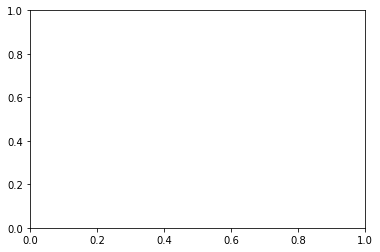

In [173]:
plt.plot(x000)

In [ ]:
with open("Flux_Shallow_5_64_1_1_w100.pickle", "wb") as fw:
    pickle.dump(model, fw)

# =====

In [ ]:
"""
@author: Zongyi Li
This file is the Fourier Neural Operator for 1D problem such as the (time-independent) Burgers equation discussed in Section 5.1 in the [paper](https://arxiv.org/pdf/2010.08895.pdf).
"""
del F
import os
import pickle
from timeit import default_timer

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from utilities3 import *


################################################################
# fourier layer
################################################################
class SpectralConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, modes1, modes2):
        super(SpectralConv2d, self).__init__()

        """
        2D Fourier layer. It does FFT, linear transform, and Inverse FFT.    
        """

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes1 = (
            modes1  # Number of Fourier modes to multiply, at most floor(N/2) + 1
        )
        self.modes2 = modes2

        self.scale = 1 / (in_channels * out_channels)
        self.weights1 = nn.Parameter(
            self.scale
            * torch.rand(
                in_channels, out_channels, self.modes1, self.modes2, dtype=torch.cfloat
            )
        )
        self.weights2 = nn.Parameter(
            self.scale
            * torch.rand(
                in_channels, out_channels, self.modes1, self.modes2, dtype=torch.cfloat
            )
        )

    # Complex multiplication
    def compl_mul2d(self, input, weights):
        # (batch, in_channel, x,y ), (in_channel, out_channel, x,y) -> (batch, out_channel, x,y)
        return torch.einsum("bixy,ioxy->boxy", input, weights)

    def forward(self, x):
        batchsize = x.shape[0]
        # Compute Fourier coeffcients up to factor of e^(- something constant)
        x_ft = torch.fft.rfft2(x)

        # Multiply relevant Fourier modes
        out_ft = torch.zeros(
            batchsize,
            self.out_channels,
            x.size(-2),
            x.size(-1) // 2 + 1,
            dtype=torch.cfloat,
            device=x.device,
        )
        out_ft[:, :, : self.modes1, : self.modes2] = self.compl_mul2d(
            x_ft[:, :, : self.modes1, : self.modes2], self.weights1
        )
        out_ft[:, :, -self.modes1 :, : self.modes2] = self.compl_mul2d(
            x_ft[:, :, -self.modes1 :, : self.modes2], self.weights2
        )

        # Return to physical space
        x = torch.fft.irfft2(out_ft, s=(x.size(-2), x.size(-1)))
        return x


class FNO2d(nn.Module):
    def __init__(self, modes1, modes2, width):
        super(FNO2d, self).__init__()

        """
        The overall network. It contains 4 layers of the Fourier layer.
        1. Lift the input to the desire channel dimension by self.fc0 .
        2. 4 layers of the integral operators u' = (W + K)(u).
            W defined by self.w; K defined by self.conv .
        3. Project from the channel space to the output space by self.fc1 and self.fc2 .
        
        input: the solution of the coefficient function and locations (a(x, y), x, y)
        input shape: (batchsize, x=s, y=s, c=3)
        output: the solution 
        output shape: (batchsize, x=s, y=s, c=1)
        """

        self.modes1 = modes1
        self.modes2 = modes2
        self.width = width
        self.padding = 9  # pad the domain if input is non-periodic
        self.fc0 = nn.Linear(3, self.width)  # input channel is 3: (a(x, y), x, y)

        self.conv0 = SpectralConv2d(self.width, self.width, self.modes1, self.modes2)
        self.conv1 = SpectralConv2d(self.width, self.width, self.modes1, self.modes2)
        self.conv2 = SpectralConv2d(self.width, self.width, self.modes1, self.modes2)
        self.conv3 = SpectralConv2d(self.width, self.width, self.modes1, self.modes2)
        self.w0 = nn.Conv2d(self.width, self.width, 1)
        self.w1 = nn.Conv2d(self.width, self.width, 1)
        self.w2 = nn.Conv2d(self.width, self.width, 1)
        self.w3 = nn.Conv2d(self.width, self.width, 1)

        self.fc1 = nn.Linear(self.width, 128)
        self.fc2 = nn.Linear(128, 1)

    def forward(self, x):
        grid = self.get_grid(x.shape, x.device)
        x = torch.cat((x, grid), dim=-1)
        x = self.fc0(x)
        x = x.permute(0, 3, 1, 2)
        x = F.pad(x, [0, self.padding, 0, self.padding])

        x1 = self.conv0(x)
        x2 = self.w0(x)
        x = x1 + x2
        x = F.gelu(x)

        x1 = self.conv1(x)
        x2 = self.w1(x)
        x = x1 + x2
        x = F.gelu(x)

        x1 = self.conv2(x)
        x2 = self.w2(x)
        x = x1 + x2
        x = F.gelu(x)

        x1 = self.conv3(x)
        x2 = self.w3(x)
        x = x1 + x2

        x = x[..., : -self.padding, : -self.padding]
        x = x.permute(0, 2, 3, 1)
        x = self.fc1(x)
        x = F.gelu(x)
        x = self.fc2(x)

        return x

    def get_grid(self, shape, device):
        batchsize, size_x, size_y = shape[0], shape[1], shape[2]
        gridx = torch.tensor(np.linspace(0, 1, size_x), dtype=torch.float)
        gridx = gridx.reshape(1, size_x, 1, 1).repeat([batchsize, 1, size_y, 1])
        gridy = torch.tensor(np.linspace(0, 1, size_y), dtype=torch.float)
        gridy = gridy.reshape(1, 1, size_y, 1).repeat([batchsize, size_x, 1, 1])
        return torch.cat((gridx, gridy), dim=-1).to(device)


class SpectralConv1d(nn.Module):
    def __init__(self, in_channels, out_channels, modes1):
        super(SpectralConv1d2, self).__init__()

        """
        1D Fourier layer. It does FFT, linear transform, and Inverse FFT.    
        """

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes1 = (
            modes1  # Number of Fourier modes to multiply, at most floor(N/2) + 1
        )

        self.scale = 1 / (in_channels * out_channels)
        self.weights1 = nn.Parameter(
            self.scale
            * torch.rand(in_channels, out_channels, self.modes1, dtype=torch.cfloat)
        )

    # Complex multiplication
    def compl_mul1d(self, input, weights):
        # (batch, in_channel, x ), (in_channel, out_channel, x) -> (batch, out_channel, x)
        return torch.einsum("bix,iox->box", input, weights)

    def forward(self, x):
        batchsize = x.shape[0]
        # Compute Fourier coeffcients up to factor of e^(- something constant)
        x_ft = torch.fft.rfft(x)

        # Multiply relevant Fourier modes
        out_ft = torch.zeros(
            batchsize,
            self.out_channels,
            x.size(-1) // 2 + 1,
            device=x.device,
            dtype=torch.cfloat,
        )
        out_ft[:, :, : self.modes1] = self.compl_mul1d(
            x_ft[:, :, : self.modes1], self.weights1
        )

        # Return to physical space
        x = torch.fft.irfft(out_ft, n=x.size(-1))
        return x


class FNO1d(nn.Module):
    def __init__(self, modes, width, depth, kernz):
        super(FNO1d, self).__init__()

        """
        The overall network. It contains 4 layers of the Fourier layer.
        1. Lift the input to the desire channel dimension by self.fc0 .
        2. 4 layers of the integral operators u' = (W + K)(u).
            W defined by self.w; K defined by self.conv .
        3. Project from the channel space to the output space by self.fc1 and self.fc2 .
        
        input: the solution of the initial condition and location (a(x), x)
        input shape: (batchsize, x=s, c=2)
        output: the solution of a later timestep
        output shape: (batchsize, x=s, c=1)
        """

        self.modes1 = modes
        self.width = width
        self.depth = depth
        self.kernelsize = kernz
        self.padding = 2  # pad the domain if input is non-periodic
        self.fc0 = nn.Linear(3, self.width, bias=False)  # input channel is 2: (a(x), x)

        self.fouriers = nn.ModuleList(
            [
                SpectralConv1d2(self.width, self.width, self.modes1)
                for i in range(self.depth)
            ]
        )
        self.convs = nn.ModuleList(
            [
                nn.Conv1d(
                    self.width,
                    self.width,
                    self.kernelsize,
                    padding=int(self.kernelsize / 2),
                )
                for i in range(self.depth)
            ]
        )

        self.relu = nn.GELU()

        self.fc1 = nn.Linear(self.width, 128, bias=False)
        self.fc2 = nn.Linear(128, 2)

    def forward(self, x):
        grid = self.get_grid(x.shape, x.device)
        x = torch.cat((x, grid), dim=-1)
        # print(x.shape)
        x = self.fc0(x)
        # print(x.shape)
        x = x.permute(0, 2, 1)
        # print(x.shape)
        # x = F.pad(x, [0,self.padding]) # pad the domain if input is non-periodic

        x0 = x

        for i in range(self.depth):
            x1 = self.fouriers[i](x)
            x2 = self.convs[i](x)

            x = self.relu(x1 + x2)
            # x0 = x
            # x = self.relu(x1)

        # x = x[..., :-self.padding] # pad the domain if input is non-periodic
        x = x.permute(0, 2, 1)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)

        return x

    def get_grid(self, shape, device):
        batchsize, size_x = shape[0], shape[1]
        gridx = torch.tensor(np.linspace(0, 1, size_x), dtype=torch.float)
        gridx = gridx.reshape(1, size_x, 1).repeat([batchsize, 1, 1])
        return gridx.to(device)

In [ ]:
for datas in ["TEST_SHALLOW_10_0.1_256"]:
    with open("./data/" + datas + ".pickle", "rb") as fr:
        train_raw_set_loaded = pickle.load(fr)

    x_test_2D = torch.cat(
        (
            (
                torch.tensor(
                    train_raw_set_loaded["train_X"][0][0], dtype=torch.float
                ).T.unsqueeze(-1)[0:512]
            ),
            (
                torch.tensor(
                    train_raw_set_loaded["train_X"][0][1], dtype=torch.float
                ).T.unsqueeze(-1)[0:512]
            ),
        ),
        dim=2,
    )

    # for i in range(len(train_raw_set_loaded['train_X'])):

    for i in range(1, 10):
        x_test_2D = torch.cat(
            (
                x_test_2D,
                torch.cat(
                    (
                        torch.tensor(
                            train_raw_set_loaded["train_X"][i][0], dtype=torch.float
                        ).T.unsqueeze(-1)[0:512],
                        torch.tensor(
                            train_raw_set_loaded["train_X"][i][1], dtype=torch.float
                        ).T.unsqueeze(-1)[0:512],
                    ),
                    dim=2,
                ),
            )
        )
        y_test_2D = torch.roll(x_test_2D, -100, dims=0)
        # x_train.append((torch.tensor(train_raw_set_loaded['train_X'][i][0], dtype=torch.float).unsqueeze(-1), torch.tensor(train_raw_set_loaded['train_X'][i][1], dtype=torch.float)))

    # x_test_2D = x_test_2D[0:x_test_2D.shape[0] - 100].view(int((x_test_2D.shape[0] - 100)/100), 100, 256, 1)
    # y_test_2D = y_test_2D[0:y_test_2D.shape[0] - 100].view(int((y_test_2D.shape[0] - 100)/100), 100, 256, 1)

In [5]:
x_test_2D.shape

torch.Size([5120, 256, 2])

In [ ]:
with open(file="Flux_Shallow_5_64_1_1_w100.pickle", mode="rb") as f:
    model = pickle.load(f)

Flux_model = model

In [ ]:
with open(file="Regular_2D_Shallow_5_10_64.pickle", mode="rb") as f:
    Reg_2D_model = pickle.load(f)

In [ ]:
with open(file="Regular_Shallow_snap_20_32_3_1.pickle", mode="rb") as f:
    Reg_snap_model = pickle.load(f)


In [ ]:
X = x_test_2D[0:100].unsqueeze(0).cuda()

N = 152

Reg_2D_model.eval()

with torch.no_grad():
    for i in range(N):
        X = Reg_2D_model(X)


Y = y_test_2D[100 * N : 100 * N + 100].unsqueeze(0)

In [ ]:
X = x_test_2D[0:100].unsqueeze(0).cuda()

longX = X

N = 152

Reg_2D_model.eval()

with torch.no_grad():
    for i in range(N):
        X = Reg_2D_model(X)

        longX = torch.cat((longX, X))


Y = y_test_2D[100 * N : 100 * N + 100].unsqueeze(0)

In [ ]:
NN = 0

x0 = x_test[NN][0][0].unsqueeze(0).cuda()


xx = [x0]
Reg_heav_model.eval()

with torch.no_grad():
    for i in range(16000):
        x0 = Reg_heav_model(x0)
        # x0 = Reg_model(x0)
        xx.append(x0)

In [ ]:
Flux_model.eval()

with torch.no_grad():
    x0 = x_test[NN][0][0].unsqueeze(0).cuda()
    f1 = Flux_model(torch.cat((torch.roll(x0.cuda(), 1, dims=1), x0.cuda()), dim=2))[0]
    f0 = Flux_model(torch.cat((x0.cuda(), torch.roll(x0.cuda(), -1, dims=1)), dim=2))[0]
    t1 = (
        torch.roll(x_test2[NN][1].cuda(), -1, dims=0)
        .unsqueeze(-1)
        .unsqueeze(-1)[0]
        .unsqueeze(0)
    )

    xx2 = [x0]
    T = 0
    for i in range(17536):
        T += t1
        x0 = x0 - t1 / (1 / 256) * (f0 - f1)
        f1 = Flux_model(
            torch.cat((torch.roll(x0.cuda(), 1, dims=1), x0.cuda()), dim=2)
        )[0]
        f0 = Flux_model(
            torch.cat((x0.cuda(), torch.roll(x0.cuda(), -1, dims=1)), dim=2)
        )[0]
        t1 = (
            torch.roll(x_test[NN][1].cuda(), -(i + 2), dims=0)
            .unsqueeze(-1)
            .unsqueeze(-1)[0]
            .unsqueeze(0)
        )
        if i % 1 == 0:
            xx2.append(x0)

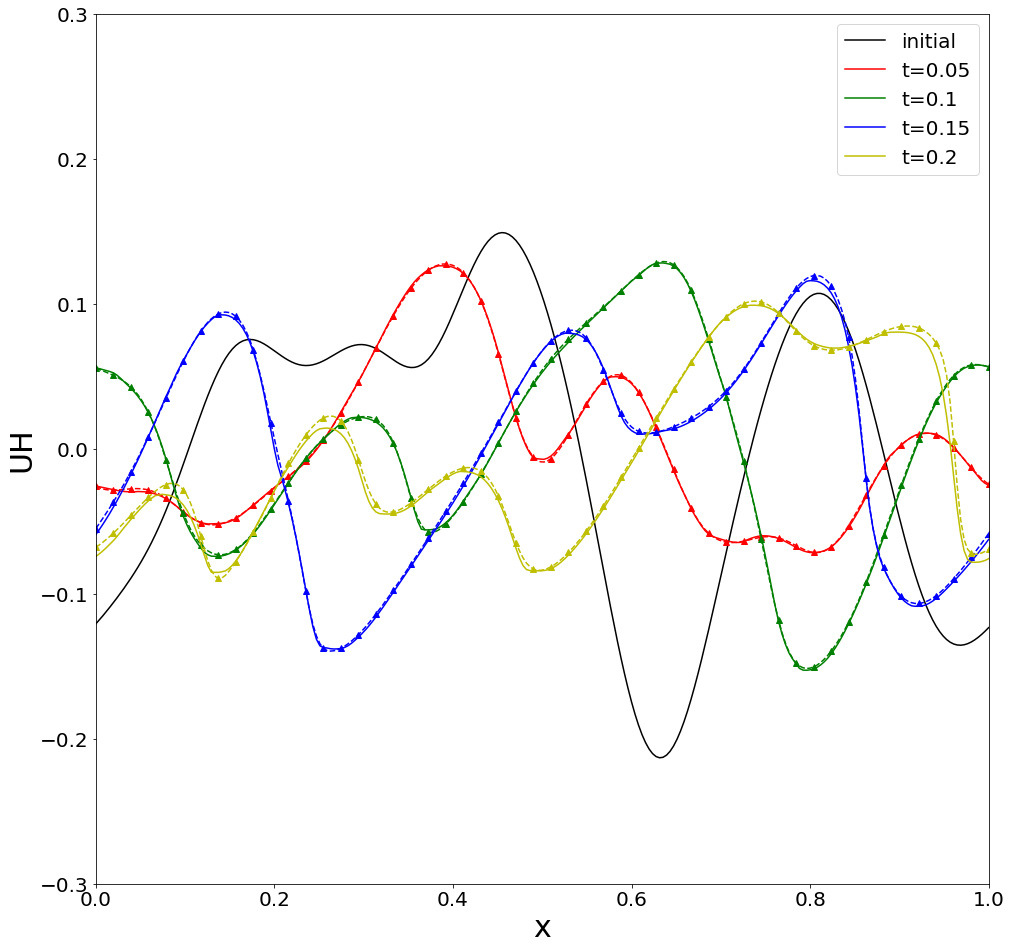

In [ ]:
plt.figure(figsize=(16, 16))

plt.xlim([0, 1])
plt.ylim([-0.3, 0.3])
plt.xlabel("x", fontsize=30)
plt.ylabel("UH", fontsize=30)
plt.plot(
    np.linspace(0, 1, 256), x_test[NN][0, :, 1].detach().cpu(), "black", label="initial"
)
plt.plot(
    np.linspace(0, 1, 256), x_test[NN][127, :, 1].detach().cpu(), "red", label="t=0.05"
)
plt.plot(
    np.linspace(0, 1, 256), xx2[127][:, :, 1].detach().cpu()[0], "--^r", markevery=5
)
plt.plot(
    np.linspace(0, 1, 256), x_test[NN][255, :, 1].detach().cpu(), "green", label="t=0.1"
)
plt.plot(
    np.linspace(0, 1, 256), xx2[255][:, :, 1].detach().cpu()[0], "--g^", markevery=5
)
plt.plot(
    np.linspace(0, 1, 256),
    x_test[NN][128 * 3 - 1, :, 1].detach().cpu(),
    "blue",
    label="t=0.15",
)
plt.plot(
    np.linspace(0, 1, 256),
    xx2[128 * 3 - 1][:, :, 1].detach().cpu()[0],
    "--b^",
    markevery=5,
)
plt.plot(
    np.linspace(0, 1, 256), x_test[NN][511, :, 1].detach().cpu(), "y", label="t=0.2"
)
plt.plot(
    np.linspace(0, 1, 256), xx2[511][:, :, 1].detach().cpu()[0], "--y^", markevery=5
)
plt.tick_params(axis="both", which="major", labelsize=20)
plt.legend(fontsize=20)

plt.savefig("Flux_FNO_Shallow_UH.png")

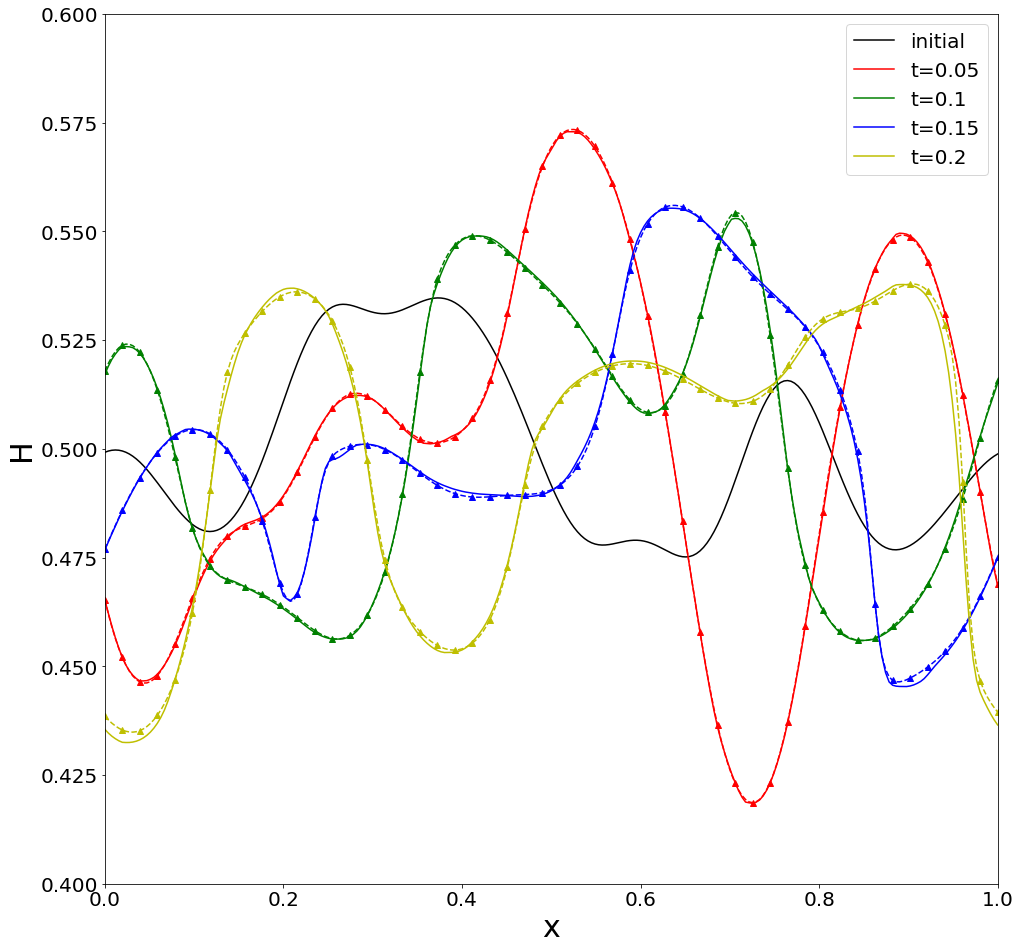

In [ ]:
plt.figure(figsize=(16, 16))

plt.xlim([0, 1])
plt.ylim([0.5 - 0.1, 0.5 + 0.1])
plt.xlabel("x", fontsize=30)
plt.ylabel("H", fontsize=30)
plt.plot(
    np.linspace(0, 1, 256), x_test[NN][0, :, 0].detach().cpu(), "black", label="initial"
)
plt.plot(
    np.linspace(0, 1, 256), x_test[NN][127, :, 0].detach().cpu(), "red", label="t=0.05"
)
plt.plot(
    np.linspace(0, 1, 256), xx2[127][:, :, 0].detach().cpu()[0], "--^r", markevery=5
)
plt.plot(
    np.linspace(0, 1, 256), x_test[NN][255, :, 0].detach().cpu(), "green", label="t=0.1"
)
plt.plot(
    np.linspace(0, 1, 256), xx2[255][:, :, 0].detach().cpu()[0], "--g^", markevery=5
)
plt.plot(
    np.linspace(0, 1, 256),
    x_test[NN][128 * 3 - 1, :, 0].detach().cpu(),
    "blue",
    label="t=0.15",
)
plt.plot(
    np.linspace(0, 1, 256),
    xx2[128 * 3 - 1][:, :, 0].detach().cpu()[0],
    "--b^",
    markevery=5,
)
plt.plot(
    np.linspace(0, 1, 256), x_test[NN][511, :, 0].detach().cpu(), "y", label="t=0.2"
)
plt.plot(
    np.linspace(0, 1, 256), xx2[511][:, :, 0].detach().cpu()[0], "--y^", markevery=5
)
plt.tick_params(axis="both", which="major", labelsize=20)
plt.legend(fontsize=20)

plt.savefig("Flux_FNO_Shallow_H.png")

In [22]:
longX.shape

torch.Size([153, 100, 256, 1])

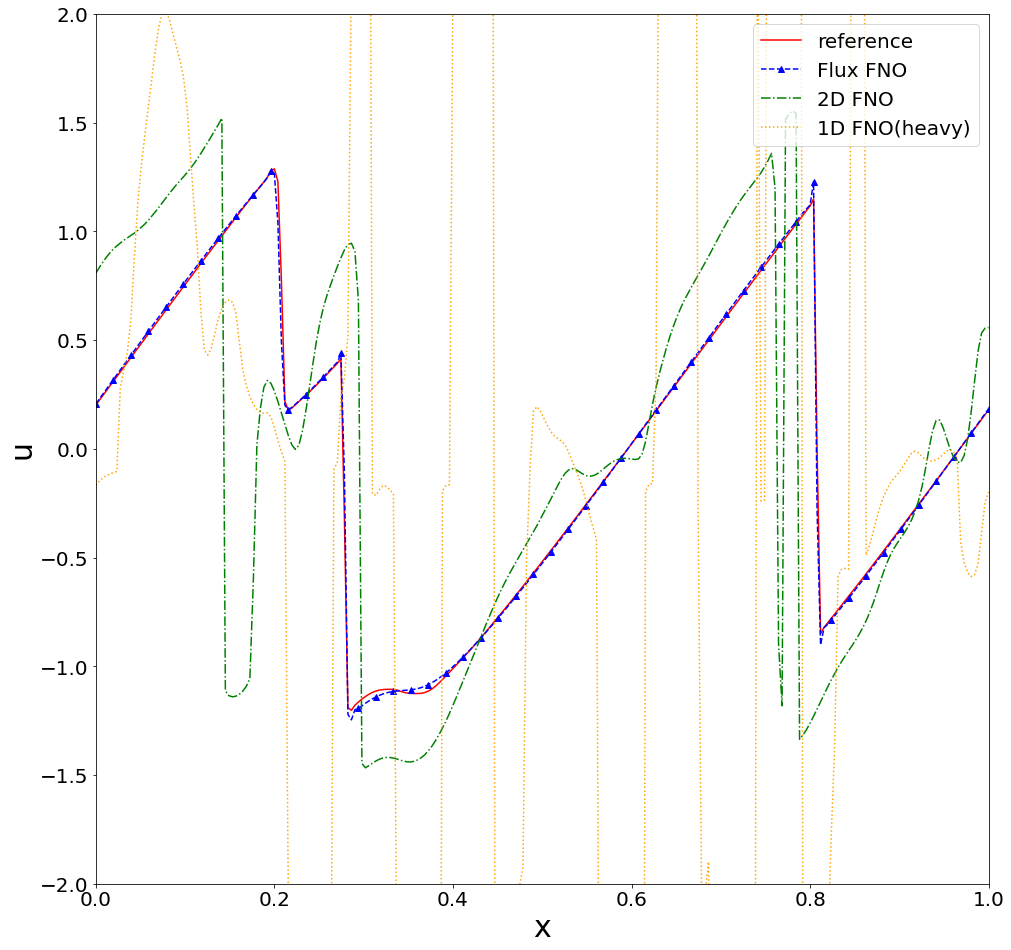

In [ ]:
plt.figure(figsize=(16, 16))

plt.xlim([0, 1])
plt.ylim([-2, 2])
plt.xlabel("x", fontsize=30)
plt.ylabel("u", fontsize=30)
plt.plot(
    np.linspace(0, 1, 256), x_test[NN][0][3840].detach().cpu(), "r", label="reference"
)
plt.plot(
    np.linspace(0, 1, 256),
    xx2[3840].detach().cpu()[0],
    "--b^",
    label="Flux FNO",
    markevery=5,
)
plt.plot(np.linspace(0, 1, 256), longX[38][40].detach().cpu(), "-.g", label="2D FNO")
plt.plot(
    np.linspace(0, 1, 256),
    xx[3840].detach().cpu().squeeze(),
    ":",
    c="orange",
    label="1D FNO(heavy)",
)
plt.legend(loc="upper right", fontsize=20)
plt.tick_params(axis="both", which="major", labelsize=20)

plt.savefig("Burgers_Comparison_0.15_2.png")

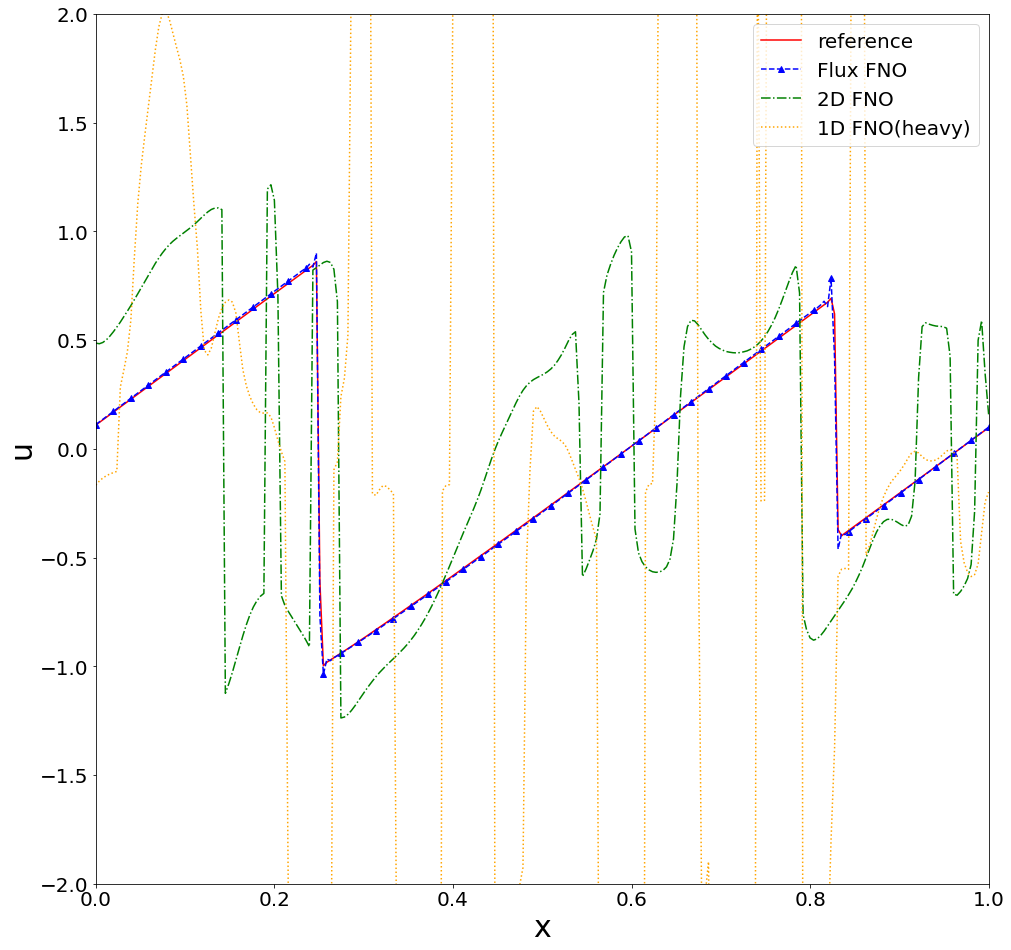

In [ ]:
plt.figure(figsize=(16, 16))

plt.xlim([0, 1])
plt.ylim([-2, 2])
plt.xlabel("x", fontsize=30)
plt.ylabel("u", fontsize=30)
plt.plot(
    np.linspace(0, 1, 256),
    x_test[NN][0][3840 * 2].detach().cpu(),
    "r",
    label="reference",
)
plt.plot(
    np.linspace(0, 1, 256),
    xx2[3840 * 2].detach().cpu()[0],
    "--b^",
    label="Flux FNO",
    markevery=5,
)
plt.plot(np.linspace(0, 1, 256), longX[76][80].detach().cpu(), "-.g", label="2D FNO")
plt.plot(
    np.linspace(0, 1, 256),
    xx[3840 * 2].detach().cpu().squeeze(),
    ":",
    c="orange",
    label="1D FNO(heavy)",
)
plt.legend(fontsize=20)
plt.tick_params(axis="both", which="major", labelsize=20)

plt.savefig("Burgers_Comparison_0.30_2.png")

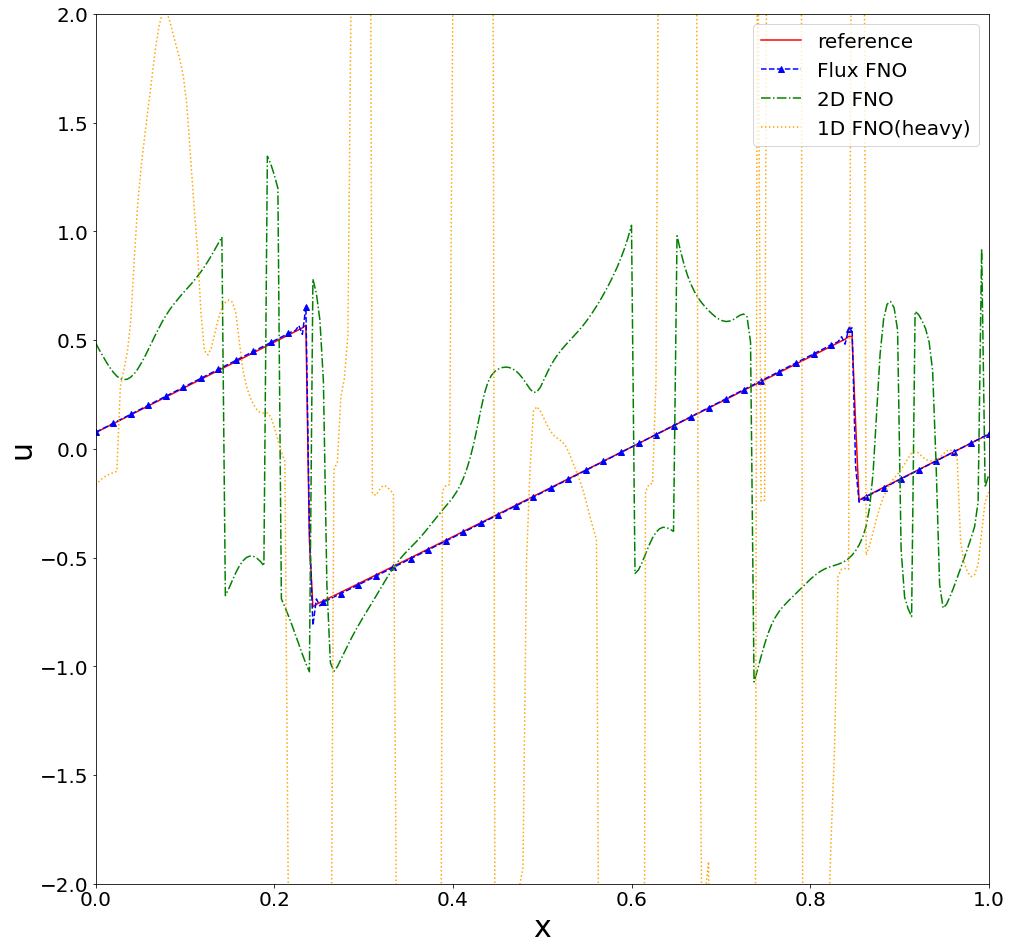

In [ ]:
plt.figure(figsize=(16, 16))

plt.xlim([0, 1])
plt.ylim([-2, 2])
plt.xlabel("x", fontsize=30)
plt.ylabel("u", fontsize=30)
plt.plot(
    np.linspace(0, 1, 256),
    x_test[NN][0][3840 * 3].detach().cpu(),
    "r",
    label="reference",
)
plt.plot(
    np.linspace(0, 1, 256),
    xx2[11520].detach().cpu()[0],
    "--b^",
    label="Flux FNO",
    markevery=5,
)
plt.plot(np.linspace(0, 1, 256), longX[115][20].detach().cpu(), "-.g", label="2D FNO")
plt.plot(
    np.linspace(0, 1, 256),
    xx[11520].detach().cpu().squeeze(),
    ":",
    c="orange",
    label="1D FNO(heavy)",
)
plt.legend(fontsize=20)
plt.tick_params(axis="both", which="major", labelsize=20)

plt.savefig("Burgers_Comparison_0.45_2.png")

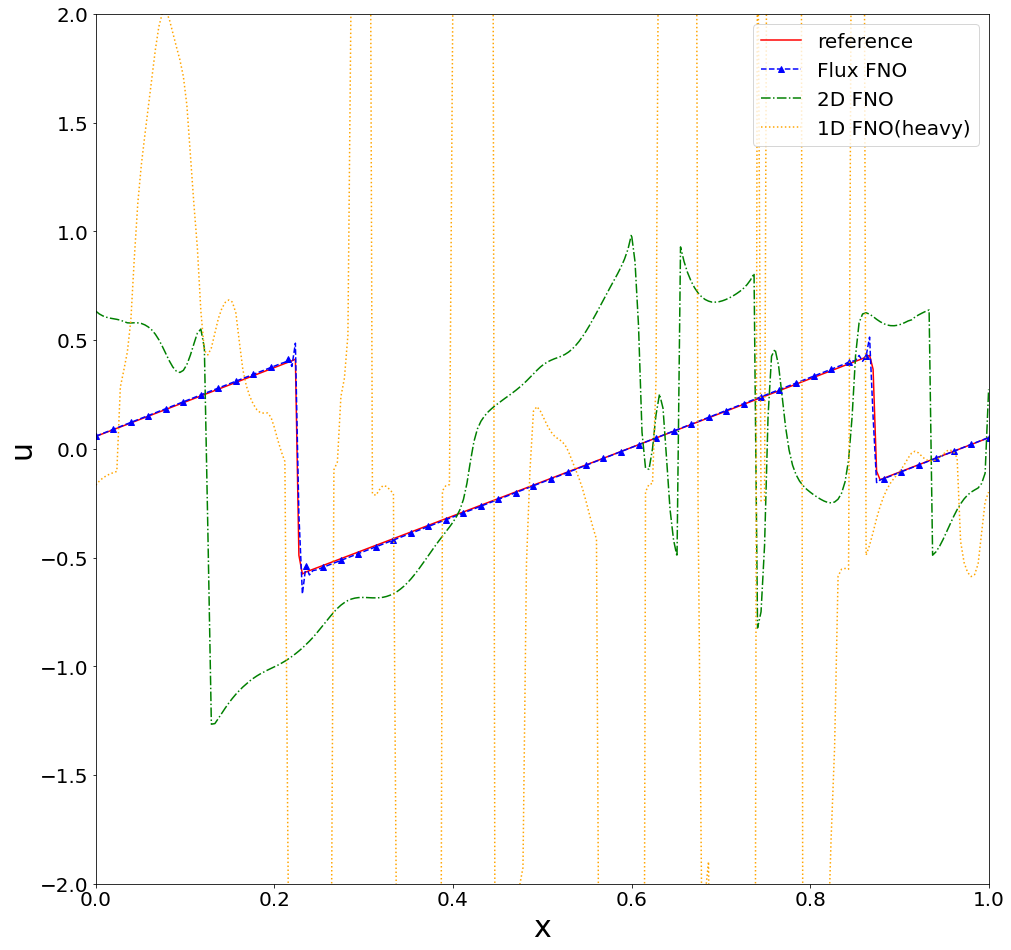

In [ ]:
plt.figure(figsize=(16, 16))

plt.xlim([0, 1])
plt.ylim([-2, 2])
plt.xlabel("x", fontsize=30)
plt.ylabel("u", fontsize=30)
plt.plot(
    np.linspace(0, 1, 256),
    x_test[NN][0][2560 * 6].detach().cpu(),
    "r",
    label="reference",
)
plt.plot(
    np.linspace(0, 1, 256),
    xx2[15260].detach().cpu()[0],
    "--b^",
    label="Flux FNO",
    markevery=5,
)
plt.plot(np.linspace(0, 1, 256), longX[152][59].detach().cpu(), "-.g", label="2D FNO")
plt.plot(
    np.linspace(0, 1, 256),
    xx[15260].detach().cpu().squeeze(),
    ":",
    c="orange",
    label="1D FNO(heavy)",
)
plt.legend(fontsize=20)
plt.tick_params(axis="both", which="major", labelsize=20)

plt.savefig("Burgers_Comparison_0.60_2.png")

In [ ]:
torch.norm(X[0][0].detach().cpu() - Y[0][0].detach().cpu()) / torch.norm(
    Y[0][0].detach().cpu()
)

tensor(1.1280)

In [28]:
x[3840]

IndexError: index 3840 is out of bounds for dimension 0 with size 100

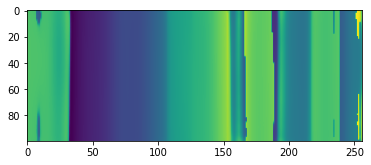

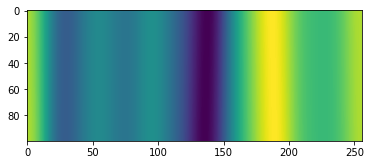

In [29]:
plt.imshow(X.detach().cpu().squeeze())
plt.show()
plt.imshow(Y.detach().cpu().squeeze())
plt.show()

In [ ]:
# print(torch.norm(Y[0][40].cuda()-xx2[3840])/torch.norm(Y[0][40].cuda()))
# print(torch.norm(Y[0][40].cuda()-X[0][40])/torch.norm(Y[0][40].cuda()))
print(
    torch.norm(x_test[NN][0][3840 * 1].cuda() - xx[3840])
    / torch.norm(x_test[NN][0][3840 * 1].cuda())
)

tensor(4.9892, device='cuda:0')


In [ ]:
print(torch.max(x_test[NN][0][3840 * 1].cuda() - xx2[3840]))
print(torch.max(x_test[NN][0][3840 * 1].cuda() - xx[3840]))
print(torch.max(x_test[NN][0][3840 * 1].cuda() - longX.view(15300, 256, 1)[3840]))

tensor(0.1590, device='cuda:0')
tensor(7.3682, device='cuda:0')
tensor(2.3900, device='cuda:0')


In [ ]:
# print(torch.norm(Y[0][80].cuda()-xx2[7680])/torch.norm(Y[0][80].cuda()))
# print(torch.norm(Y[0][80].cuda()-X[0][80])/torch.norm(Y[0][80].cuda()))
print(
    torch.norm(x_test[NN][0][3840 * 2].cuda() - xx[7680])
    / torch.norm(x_test[NN][0][3840 * 2].cuda())
)

tensor(7.3153, device='cuda:0')


In [ ]:
print(torch.max(x_test[NN][0][3840 * 2].cuda() - xx2[3840 * 2]))
print(torch.max(x_test[NN][0][3840 * 2].cuda() - xx[3840 * 2]))
print(torch.max(x_test[NN][0][3840 * 2].cuda() - longX.view(15300, 256, 1)[3840 * 2]))

tensor(0.1497, device='cuda:0')
tensor(7.0539, device='cuda:0')
tensor(1.7419, device='cuda:0')


In [ ]:
# print(torch.norm(x_test[NN][0][3840*3].cuda()-xx2[11520])/torch.norm(Y[0][20].cuda()))
# print(torch.norm(x_test[NN][0][3840*3].cuda()-X[0][20])/torch.norm(Y[0][20].cuda()))
print(
    torch.norm(x_test[NN][0][3840 * 3].cuda() - xx[11520])
    / torch.norm(x_test[NN][0][3840 * 3].cuda())
)

tensor(10.2075, device='cuda:0')


In [ ]:
print(torch.max(x_test[NN][0][3840 * 3].cuda() - xx2[3840 * 3]))
print(torch.max(x_test[NN][0][3840 * 3].cuda() - xx[3840 * 3]))
print(torch.max(x_test[NN][0][3840 * 3].cuda() - longX.view(15300, 256, 1)[3840 * 3]))

tensor(0.1994, device='cuda:0')
tensor(6.9356, device='cuda:0')
tensor(1.5294, device='cuda:0')


In [ ]:
# print(torch.norm(x_test[NN][0][2560*6].detach().cuda()-xx2[15360])/torch.norm(x_test[NN][0][2560*6].detach().cuda()))
# print(torch.norm(x_test[NN][0][2560*6].detach().cuda()-X[0][60])/torch.norm(x_test[NN][0][2560*6].detach().cuda()))
print(
    torch.norm(x_test[NN][0][2560 * 6].detach().cuda() - xx[15360])
    / torch.norm(x_test[NN][0][2560 * 6].detach().cuda())
)

tensor(19.7404, device='cuda:0')


In [ ]:
print(torch.max(x_test[NN][0][3840 * 4].cuda() - xx2[3840 * 4]))
print(torch.max(x_test[NN][0][3840 * 4].cuda() - xx[3840 * 4]))
print(
    torch.max(
        x_test[NN][0][3840 * 4 - 61].cuda() - longX.view(15300, 256, 1)[3840 * 4 - 61]
    )
)

tensor(0.1409, device='cuda:0')
tensor(6.9001, device='cuda:0')
tensor(1.5637, device='cuda:0')


In [46]:
x_test[NN][0].shape

torch.Size([15361, 256, 1])

In [ ]:
xx22 = xx2[0]

for i in range(1, 15361):
    xx22 = torch.cat((xx22, xx2[i]))


xx11 = xx[0]

for i in range(1, 15361):
    xx11 = torch.cat((xx11, xx[i]))

In [ ]:
# torch.norm(x_test[NN][0].cuda()-xx22)/torch.norm(x_test[NN][0].cuda())
torch.norm(x_test[NN][0].cuda() - xx11) / torch.norm(x_test[NN][0].cuda())
# torch.norm(x_test[0][0][0:15300].cuda() - longX.view(15300,256,1))/torch.norm(x_test[0][0].cuda())

tensor(8.5741, device='cuda:0')

In [ ]:
print(torch.max(x_test[NN][0].cuda() - xx22))
print(torch.max(x_test[NN][0].cuda() - xx11))
print(torch.max(x_test[0][0][0:15300].cuda() - longX.view(15300, 256, 1)))

tensor(0.4554, device='cuda:0')
tensor(8.0389, device='cuda:0')
tensor(3.6401, device='cuda:0')


In [15]:
x_test[0][0].cuda().shape

torch.Size([15361, 256, 1])

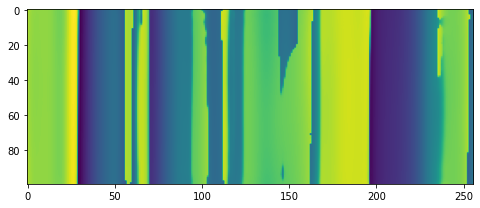

In [ ]:
plt.figure(figsize=(8, 80))
plt.imshow(X.view(100, 256, 1).cpu())

# ===

In [ ]:
lnorm = torch.zeros(3, 4, 2).cuda()


TN = 10

torch.set_printoptions(precision=10)

for NN in range(TN):
    Flux_model.eval()

    with torch.no_grad():
        x0 = x_test[NN][0].unsqueeze(0).cuda()
        f1 = Flux_model(
            torch.cat((torch.roll(x0.cuda(), 1, dims=1), x0.cuda()), dim=2)
        )[0]
        f0 = Flux_model(
            torch.cat((x0.cuda(), torch.roll(x0.cuda(), -1, dims=1)), dim=2)
        )[0]

        xx = [x0]

        for i in range(512):
            x0 = x0 - 0.1 * (f0 - f1)
            f1 = Flux_model(
                torch.cat((torch.roll(x0.cuda(), 1, dims=1), x0.cuda()), dim=2)
            )[0]
            f0 = Flux_model(
                torch.cat((x0.cuda(), torch.roll(x0.cuda(), -1, dims=1)), dim=2)
            )[0]
            if i % 1 == 0:
                xx.append(x0)

    x0 = x_test[NN][0].unsqueeze(0).cuda()

    xx2 = [x0]

    with torch.no_grad():
        for i in range(20):
            # x0 = Reg_snap_model(x0)
            # x0 = Reg_model(x0)
            xx2.append(x0)

    x0 = x_test[NN][0].unsqueeze(0).cuda()

    X = x_test_2D[512 * NN : 512 * NN + 32].unsqueeze(0).cuda()

    longX = X

    N = 18

    Reg_2D_model.eval()

    with torch.no_grad():
        for i in range(N):
            X = Reg_2D_model(X)

            longX = torch.cat((longX, X))

    for i in range(4):
        lnorm[0][i][0] += (
            torch.norm(x_test[NN][128 * (i + 1)].cuda() - xx[128 * (i + 1)].cuda())
            / torch.norm(x_test[NN][128 * (i + 1)].cuda())
            / TN
        )
        lnorm[1][i][0] += (
            torch.norm(x_test[NN][128 * (i + 1)].cuda() - xx2[2 * (i + 1)].cuda())
            / torch.norm(x_test[NN][128 * (i + 1)].cuda())
            / TN
        )
        lnorm[2][i][0] += (
            torch.norm(
                x_test[NN][128 * (i + 1)].cuda()
                - longX[4 * (i + 1)][0].unsqueeze(0).cuda()
            )
            / torch.norm(x_test[NN][128 * (i + 1)].cuda())
            / TN
        )

    for i in range(4):
        lnorm[0][i][1] += (
            torch.max(x_test[NN][128 * (i + 1)].cuda() - xx[128 * (i + 1)].cuda()) / TN
        )
        lnorm[1][i][1] += (
            torch.max(x_test[NN][128 * (i + 1)].cuda() - xx2[2 * (i + 1)].cuda()) / TN
        )
        lnorm[2][i][1] += (
            torch.max(
                x_test[NN][128 * (i + 1)].cuda()
                - longX[4 * (i + 1)][0].unsqueeze(0).cuda()
            )
            / TN
        )

    print(NN)

0
1
2
3
4
5
6
7
8
9


In [ ]:
x_test[NN][128 * (i + 1)].shape

torch.Size([256, 2])

In [120]:
lnorm

tensor([[[0.0035825749, 0.0045717903],
         [0.0056310208, 0.0055075781],
         [0.0095565626, 0.0062556751],
         [0.0153552359, 0.0073354188]],

        [[0.2454499602, 0.2399342358],
         [0.2894111872, 0.2692301869],
         [0.2740395069, 0.2494882494],
         [0.2586930692, 0.2288398445]],

        [[0.0077386843, 0.0097992653],
         [0.0121450089, 0.0157975275],
         [0.0158512592, 0.0154614924],
         [0.0188442767, 0.0156878252]]], device='cuda:0')

In [95]:
lnorm

tensor([[[1.9817e+01, 5.9436e-01],
         [3.5311e+01, 1.0112e+00],
         [5.0814e+01, 1.4294e+00],
         [6.8860e+01, 1.9072e+00]],

        [[2.1911e-03, 2.8490e-03],
         [2.9856e-03, 4.9545e-03],
         [4.4735e-03, 6.8076e-03],
         [6.3363e-03, 7.3086e-03]],

        [[7.7387e-03, 9.7993e-03],
         [1.2145e-02, 1.5798e-02],
         [1.5851e-02, 1.5461e-02],
         [1.8844e-02, 1.5688e-02]]], device='cuda:0')

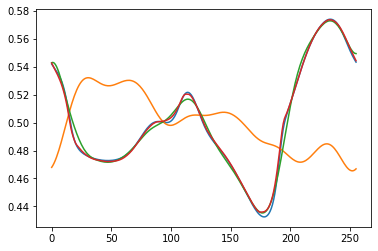

In [ ]:
lnorm[2]

i = 2
plt.plot(xx[128 * (i + 1)].cuda()[-1][:, 0].detach().cpu())
plt.plot(xx2[2 * (i + 1)].cuda()[-1][:, 0].detach().cpu())
plt.plot(longX[4 * (i + 1)][0][:, 0].detach().cpu())
plt.plot(x_test[NN][128 * (i + 1)][:, 0])

In [14]:
Reg_snap_model(x0)

IndexError: too many indices for tensor of dimension 3

In [10]:
x0.shape

torch.Size([1, 256, 2])

In [43]:
x0.shape

torch.Size([1, 2])

In [36]:
lnorm

tensor([[[ 0.0405,  0.1833],
         [ 0.0493,  0.0921],
         [ 0.0663,  0.1114],
         [ 0.0784,  0.1224],
         [ 0.0411,  0.3458]],

        [[ 4.6752,  7.8519],
         [ 6.5446,  7.5296],
         [ 8.8595,  7.3103],
         [11.1953,  7.3179],
         [ 5.3883,  8.6611]],

        [[ 5.0658,  4.8872],
         [10.0835,  4.9349],
         [15.0155,  4.9196],
         [19.0880,  4.8128],
         [ 7.7802,  5.3523]],

        [[ 0.9323,  2.2351],
         [ 1.3547,  1.6519],
         [ 1.8777,  1.4294],
         [ 2.2108,  1.2557],
         [ 1.0814,  3.2785]]], device='cuda:0')

In [60]:
lnorm

tensor([[[ 0.0475,  0.3022],
         [ 0.0491,  0.2138],
         [ 0.0512,  0.1481],
         [ 0.0517,  0.1292],
         [ 0.0396,  0.4786]],

        [[ 4.6752,  7.8519],
         [ 6.5446,  7.5296],
         [ 8.8595,  7.3103],
         [11.1953,  7.3179],
         [ 5.3883,  8.6611]],

        [[ 5.0658,  4.8872],
         [10.0835,  4.9349],
         [15.0155,  4.9196],
         [19.0880,  4.8128],
         [ 7.7802,  5.3523]],

        [[ 0.9323,  2.2351],
         [ 1.3547,  1.6519],
         [ 1.8777,  1.4294],
         [ 2.2108,  1.2557],
         [ 1.0814,  3.2785]]], device='cuda:0')

# ===

In [ ]:
for datas in ["TEST_SHALLOW_1_square_256"]:
    with open("./data/" + datas + ".pickle", "rb") as fr:
        train_raw_set_loaded = pickle.load(fr)

    x_test = []

    for i in range(len(train_raw_set_loaded["train_X"])):
        x_test.append(
            (
                torch.tensor(train_raw_set_loaded["train_X"][i][0], dtype=torch.float),
                torch.tensor(train_raw_set_loaded["train_X"][i][1], dtype=torch.float),
            )
        )


for datas in ["TEST2"]:
    with open("./data/" + datas + ".pickle", "rb") as fr:
        train_raw_set_loaded = pickle.load(fr)

    x_test2 = []

    for i in range(len(train_raw_set_loaded["train_X"])):
        x_test2.append(
            (
                torch.tensor(
                    train_raw_set_loaded["train_X"][i][0], dtype=torch.float
                ).unsqueeze(-1),
                torch.tensor(train_raw_set_loaded["train_X"][i][1], dtype=torch.float),
            )
        )


In [ ]:
for datas in ["TEST_1_0.03_256_uniform"]:
    with open("./data/" + datas + ".pickle", "rb") as fr:
        train_raw_set_loaded = pickle.load(fr)

    x_test_2D = torch.tensor(train_raw_set_loaded["train_X"][0][0], dtype=torch.float)[
        0 : (torch.tensor(train_raw_set_loaded["train_X"][0][0]).shape[0] // 64) * 64
    ]

    for i in range(1):
        x_test_2D = torch.cat(
            (
                x_test_2D,
                (
                    torch.tensor(
                        train_raw_set_loaded["train_X"][i][0], dtype=torch.float
                    ).unsqueeze(-1)[
                        0 : (
                            torch.tensor(train_raw_set_loaded["train_X"][i][0]).shape[0]
                            // 64
                        )
                        * 64
                    ]
                ),
            )
        )
        y_test_2D = torch.roll(x_test_2D, -64, dims=0)


"""
        
for datas in ['TEST2']:


    with open("./data/" + datas + ".pickle","rb") as fr:
        train_raw_set_loaded = pickle.load(fr)
    
    
    
    x_test2 = []
    
    for i in range(len(train_raw_set_loaded['train_X'])):
        
        x_test2.append((torch.tensor(train_raw_set_loaded['train_X'][i][0], dtype=torch.float).unsqueeze(-1), torch.tensor(train_raw_set_loaded['train_X'][i][1], dtype=torch.float)))
"""

RuntimeError: Tensors must have same number of dimensions: got 2 and 3

In [ ]:
torch.cat((x_test[0][0].view([2561, 256, 1]), x_test[0][1].T.unsqueeze(-1)), dim=2)[
    0:32
].shape

In [ ]:
Flux_model.eval()

NN = 0
with torch.no_grad():
    x0 = (
        torch.cat((x_test[0][0].T.unsqueeze(-1), x_test[0][1].T.unsqueeze(-1)), dim=2)[
            0
        ]
        .unsqueeze(0)
        .to(device)
    )
    f1 = Flux_model(torch.cat((torch.roll(x0.cuda(), 1, dims=1), x0.cuda()), dim=2))[0]
    f0 = Flux_model(torch.cat((x0.cuda(), torch.roll(x0.cuda(), -1, dims=1)), dim=2))[0]
    t1 = (
        torch.roll(x_test2[NN][1].cuda(), -1, dims=0)
        .unsqueeze(-1)
        .unsqueeze(-1)[0]
        .unsqueeze(0)
    )

    xx2 = [x0]
    for i in range(512):
        x0 = x0 - 0.1 * (f0 - f1)
        f1 = Flux_model(
            torch.cat((torch.roll(x0.cuda(), 1, dims=1), x0.cuda()), dim=2)
        )[0]
        f0 = Flux_model(
            torch.cat((x0.cuda(), torch.roll(x0.cuda(), -1, dims=1)), dim=2)
        )[0]
        t1 = (
            torch.roll(x_test[NN][1].cuda(), -(i + 2), dims=0)
            .unsqueeze(-1)
            .unsqueeze(-1)[0]
            .unsqueeze(0)
        )
        if i % 1 == 0:
            xx2.append(x0)

    Reg_2D_model.eval()
    N = 16
    X = (
        torch.cat((x_test[0][0].T.unsqueeze(-1), x_test[0][1].T.unsqueeze(-1)), dim=2)[
            0:32
        ]
        .unsqueeze(0)
        .cuda()
    )
    longX = X
    with torch.no_grad():
        for i in range(N):
            X = Reg_2D_model(X)

            longX = torch.cat((longX, X))

In [249]:
x_test[0][0].shape

torch.Size([256, 2561])

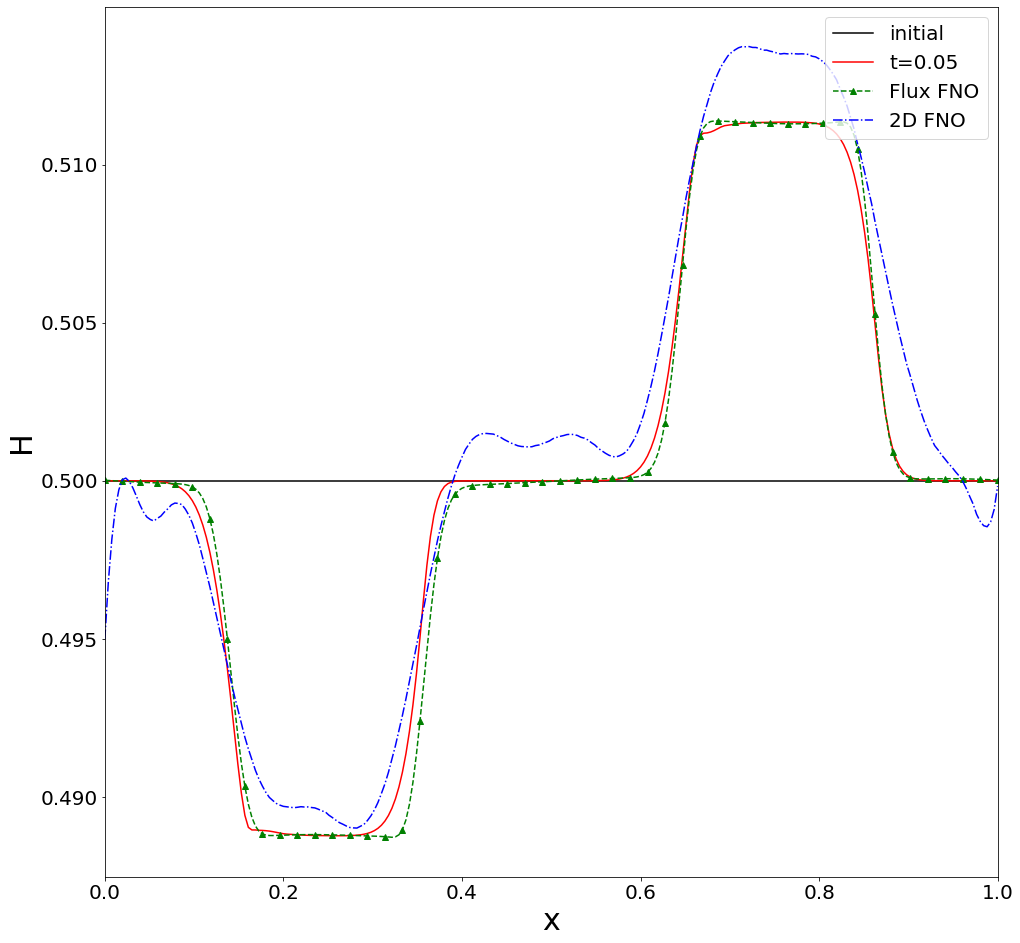

In [ ]:
plt.figure(figsize=(16, 16))

plt.xlim([0, 1])
# plt.ylim([0.5-0.2,0.5+0.2])
plt.xlabel("x", fontsize=30)
plt.ylabel("H", fontsize=30)
# plt.plot(np.linspace(0,1,256),x_test[NN][0][0].detach().cpu(), 'black', label='initial')
plt.plot(
    np.linspace(0, 1, 256), x_test[0][0][:, 0].detach().cpu(), "black", label="initial"
)
plt.plot(
    np.linspace(0, 1, 256), x_test[0][0][:, 128].detach().cpu(), "r", label="t=0.05"
)
plt.plot(
    np.linspace(0, 1, 256),
    xx2[128][0, :, 0].detach().cpu(),
    "--g^",
    label="Flux FNO",
    markevery=5,
)
plt.plot(
    np.linspace(0, 1, 256),
    longX[4][0][:, 0].squeeze().detach().cpu(),
    "-.b",
    label="2D FNO",
)
# plt.plot(np.linspace(0,1,256),xx2[204].detach().cpu()[0], '--g^', markevery = 5)
# plt.plot(np.linspace(0,1,256),x_test[NN][0][127].detach().cpu(), 'blue', label='t=2.5')
# plt.plot(np.linspace(0,1,256),xx2[639].detach().cpu()[0], '--b^', markevery = 5)
# plt.plot(np.linspace(0,1,256),x_test[NN][0][255].detach().cpu(), 'y', label='t=5.0')
# plt.plot(np.linspace(0,1,256),xx2[256*5-1].detach().cpu()[0], '--y^', markevery = 5)
plt.tick_params(axis="both", which="major", labelsize=20)
plt.legend(loc="upper right", fontsize=20)

plt.savefig("Flux_FNO_OOD_GRF_Shallow_05_H.png")

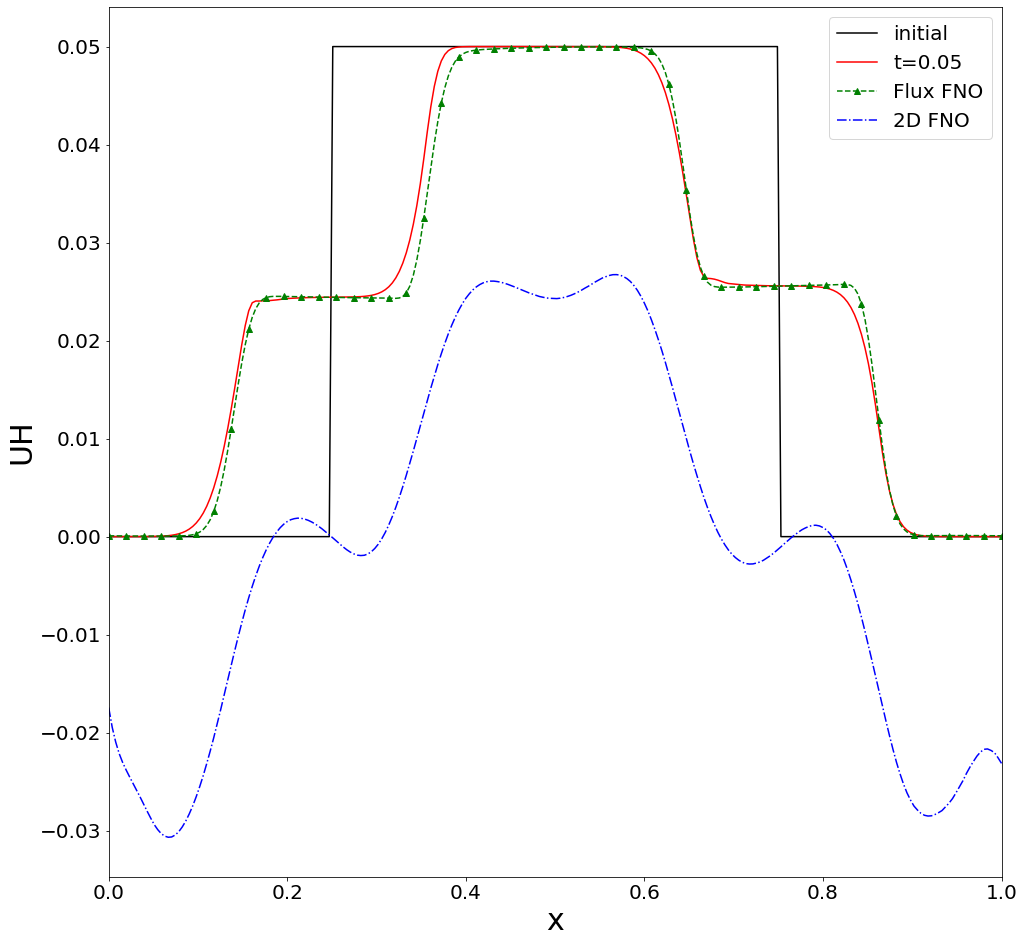

In [ ]:
plt.figure(figsize=(16, 16))

plt.xlim([0, 1])
# plt.ylim([0.5-0.2,0.5+0.2])
plt.xlabel("x", fontsize=30)
plt.ylabel("UH", fontsize=30)
# plt.plot(np.linspace(0,1,256),x_test[NN][0][0].detach().cpu(), 'black', label='initial')
plt.plot(
    np.linspace(0, 1, 256), x_test[0][1][:, 0].detach().cpu(), "black", label="initial"
)
plt.plot(
    np.linspace(0, 1, 256), x_test[0][1][:, 128].detach().cpu(), "r", label="t=0.05"
)
plt.plot(
    np.linspace(0, 1, 256),
    xx2[128][0, :, 1].detach().cpu(),
    "--g^",
    label="Flux FNO",
    markevery=5,
)
plt.plot(
    np.linspace(0, 1, 256),
    longX[4][0][:, 1].squeeze().detach().cpu(),
    "-.b",
    label="2D FNO",
)
# plt.plot(np.linspace(0,1,256),xx2[204].detach().cpu()[0], '--g^', markevery = 5)
# plt.plot(np.linspace(0,1,256),x_test[NN][0][127].detach().cpu(), 'blue', label='t=2.5')
# plt.plot(np.linspace(0,1,256),xx2[639].detach().cpu()[0], '--b^', markevery = 5)
# plt.plot(np.linspace(0,1,256),x_test[NN][0][255].detach().cpu(), 'y', label='t=5.0')
# plt.plot(np.linspace(0,1,256),xx2[256*5-1].detach().cpu()[0], '--y^', markevery = 5)
plt.tick_params(axis="both", which="major", labelsize=20)
plt.legend(loc="upper right", fontsize=20)

plt.savefig("Flux_FNO_OOD_GRF_Shallow_05_UH.png")

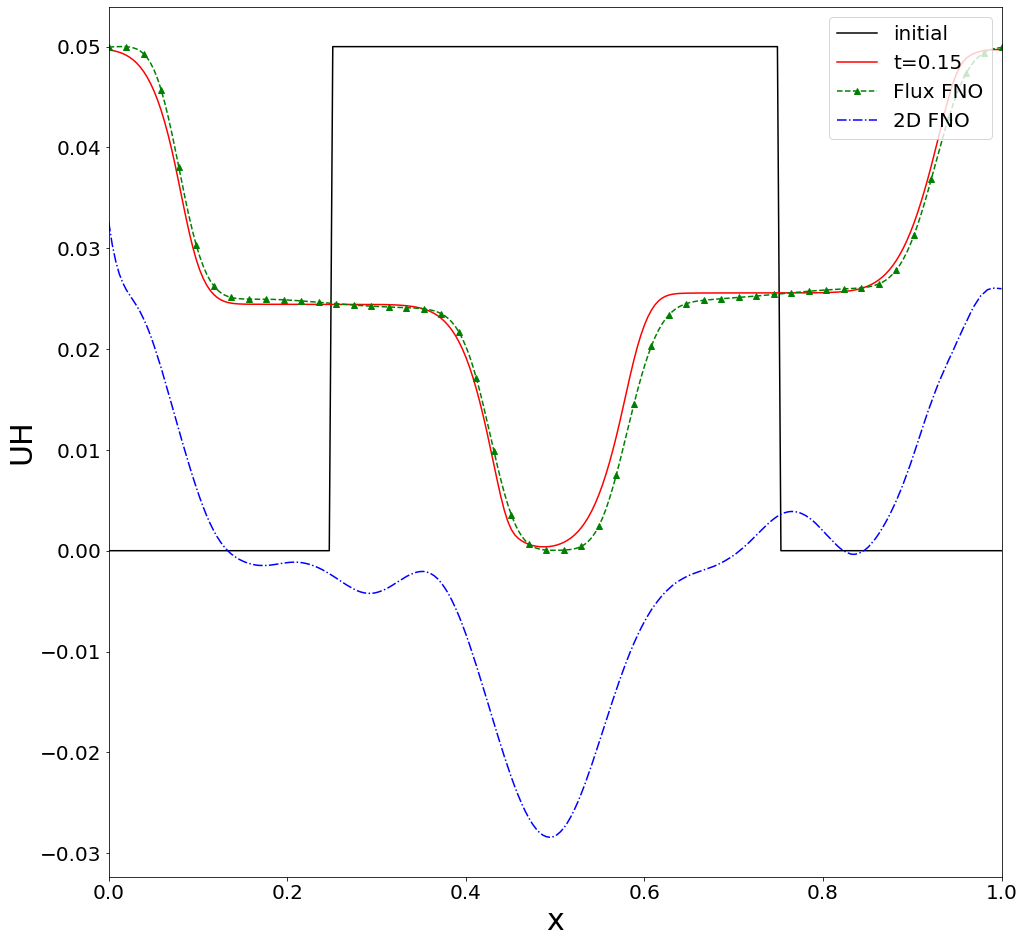

In [ ]:
plt.figure(figsize=(16, 16))

plt.xlim([0, 1])
# plt.ylim([0.5-0.2,0.5+0.2])
plt.xlabel("x", fontsize=30)
plt.ylabel("UH", fontsize=30)
# plt.plot(np.linspace(0,1,256),x_test[NN][0][0].detach().cpu(), 'black', label='initial')
plt.plot(
    np.linspace(0, 1, 256), x_test[0][1][:, 0].detach().cpu(), "black", label="initial"
)
plt.plot(
    np.linspace(0, 1, 256), x_test[0][1][:, 128 * 3].detach().cpu(), "r", label="t=0.15"
)
plt.plot(
    np.linspace(0, 1, 256),
    xx2[128 * 3][0, :, 1].detach().cpu(),
    "--g^",
    label="Flux FNO",
    markevery=5,
)
plt.plot(
    np.linspace(0, 1, 256),
    longX[12][0][:, 1].squeeze().detach().cpu(),
    "-.b",
    label="2D FNO",
)
# plt.plot(np.linspace(0,1,256),xx2[204].detach().cpu()[0], '--g^', markevery = 5)
# plt.plot(np.linspace(0,1,256),x_test[NN][0][127].detach().cpu(), 'blue', label='t=2.5')
# plt.plot(np.linspace(0,1,256),xx2[639].detach().cpu()[0], '--b^', markevery = 5)
# plt.plot(np.linspace(0,1,256),x_test[NN][0][255].detach().cpu(), 'y', label='t=5.0')
# plt.plot(np.linspace(0,1,256),xx2[256*5-1].detach().cpu()[0], '--y^', markevery = 5)
plt.tick_params(axis="both", which="major", labelsize=20)
plt.legend(loc="upper right", fontsize=20)

plt.savefig("Flux_FNO_OOD_GRF_Shallow_15_UH.png")

In [41]:
x_test[NN][0].shape

torch.Size([15361, 256, 1])

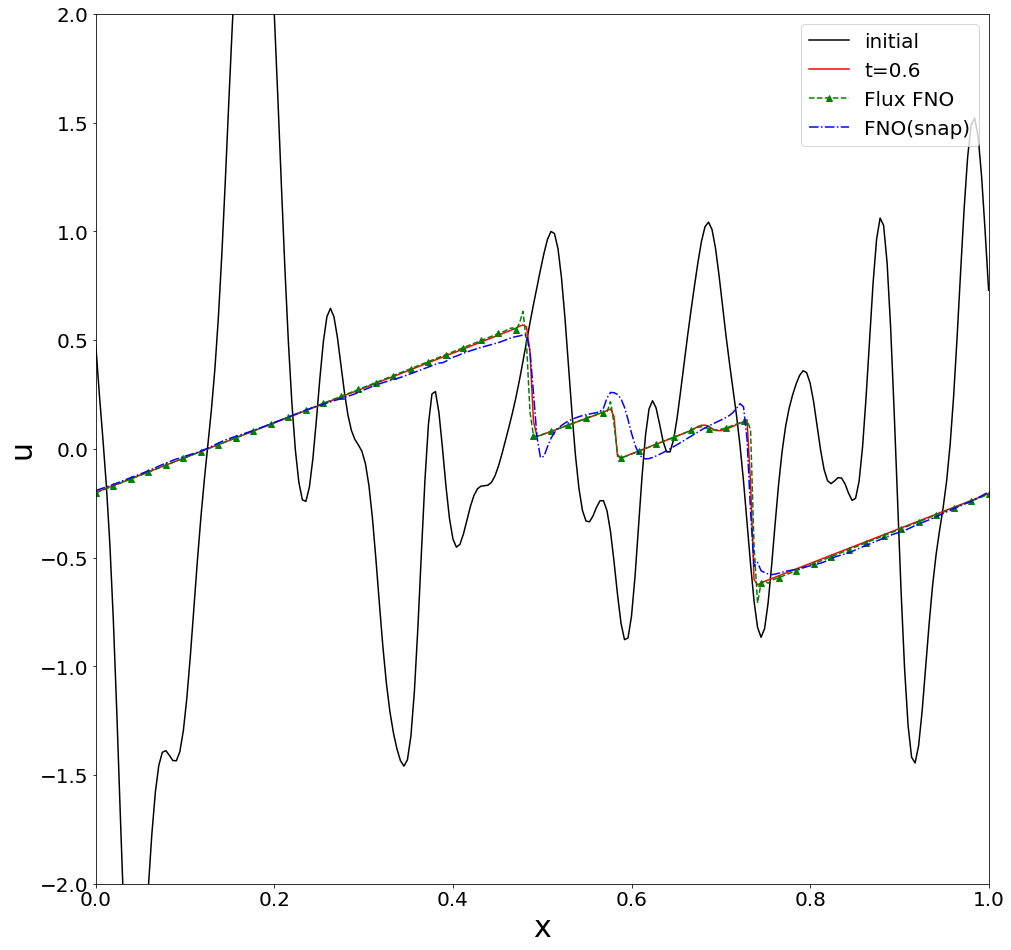

In [ ]:
plt.figure(figsize=(16, 16))

plt.xlim([0, 1])
plt.ylim([-2, 2])
plt.xlabel("x", fontsize=30)
plt.ylabel("u", fontsize=30)
# plt.plot(np.linspace(0,1,256),x_test[NN][0][0].detach().cpu(), 'black', label='initial')
plt.plot(
    np.linspace(0, 1, 256), x_test[0][0][0].detach().cpu(), "black", label="initial"
)
plt.plot(
    np.linspace(0, 1, 256), x_test[NN][0][3840 * 4].detach().cpu(), "r", label="t=0.6"
)
plt.plot(
    np.linspace(0, 1, 256),
    xx2[3840 * 4].detach().cpu()[0],
    "--g^",
    label="Flux FNO",
    markevery=5,
)
plt.plot(
    np.linspace(0, 1, 256),
    Reg_snap_model(Reg_snap_model(x_test[0][0][0].unsqueeze(0).cuda()))
    .squeeze()
    .detach()
    .cpu(),
    "-.b",
    label="FNO(snap)",
)
# plt.plot(np.linspace(0,1,256),xx2[204].detach().cpu()[0], '--g^', markevery = 5)
# plt.plot(np.linspace(0,1,256),x_test[NN][0][127].detach().cpu(), 'blue', label='t=2.5')
# plt.plot(np.linspace(0,1,256),xx2[639].detach().cpu()[0], '--b^', markevery = 5)
# plt.plot(np.linspace(0,1,256),x_test[NN][0][255].detach().cpu(), 'y', label='t=5.0')
# plt.plot(np.linspace(0,1,256),xx2[256*5-1].detach().cpu()[0], '--y^', markevery = 5)
plt.tick_params(axis="both", which="major", labelsize=20)
plt.legend(loc="upper right", fontsize=20)

plt.savefig("Flux_FNO_OOD_GRF_Burgers_06_2.png")

In [ ]:
Flux_model.eval()

A = np.zeros(256)
A[0:128] = 1

NN = 0
with torch.no_grad():
    x0 = torch.tensor(A).view(1, 256, 1).float().cuda()
    f1 = Flux_model(torch.cat((torch.roll(x0.cuda(), 1, dims=1), x0.cuda()), dim=2))[0]
    f0 = Flux_model(torch.cat((x0.cuda(), torch.roll(x0.cuda(), -1, dims=1)), dim=2))[0]
    t1 = (
        torch.roll(x_test2[NN][1].cuda(), -1, dims=0)
        .unsqueeze(-1)
        .unsqueeze(-1)[0]
        .unsqueeze(0)
    )

    xx2 = [x0]
    T = 0
    for i in range(17536):
        T += t1
        x0 = x0 - t1 / (1 / 256) * (f0 - f1)
        f1 = Flux_model(
            torch.cat((torch.roll(x0.cuda(), 1, dims=1), x0.cuda()), dim=2)
        )[0]
        f0 = Flux_model(
            torch.cat((x0.cuda(), torch.roll(x0.cuda(), -1, dims=1)), dim=2)
        )[0]
        t1 = (
            torch.roll(x_test[NN][1].cuda(), -(i + 2), dims=0)
            .unsqueeze(-1)
            .unsqueeze(-1)[0]
            .unsqueeze(0)
        )
        if i % 1 == 0:
            xx2.append(x0)

In [ ]:
A3 = np.zeros(256)
A3[0:128] = 1

for t in range(1, int(15360 / 2) + 1):
    A3[0 : 127 + int((0.5 * (t / 25600)) * 256)] = 1
    A3[0 : int((256) * (t / 25600))] = (25600 / t) * np.linspace(0, 1, 256)[
        0 : int((256) * (t / 25600))
    ]

In [20]:
np.concatenate((np.zeros(128), A3))

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

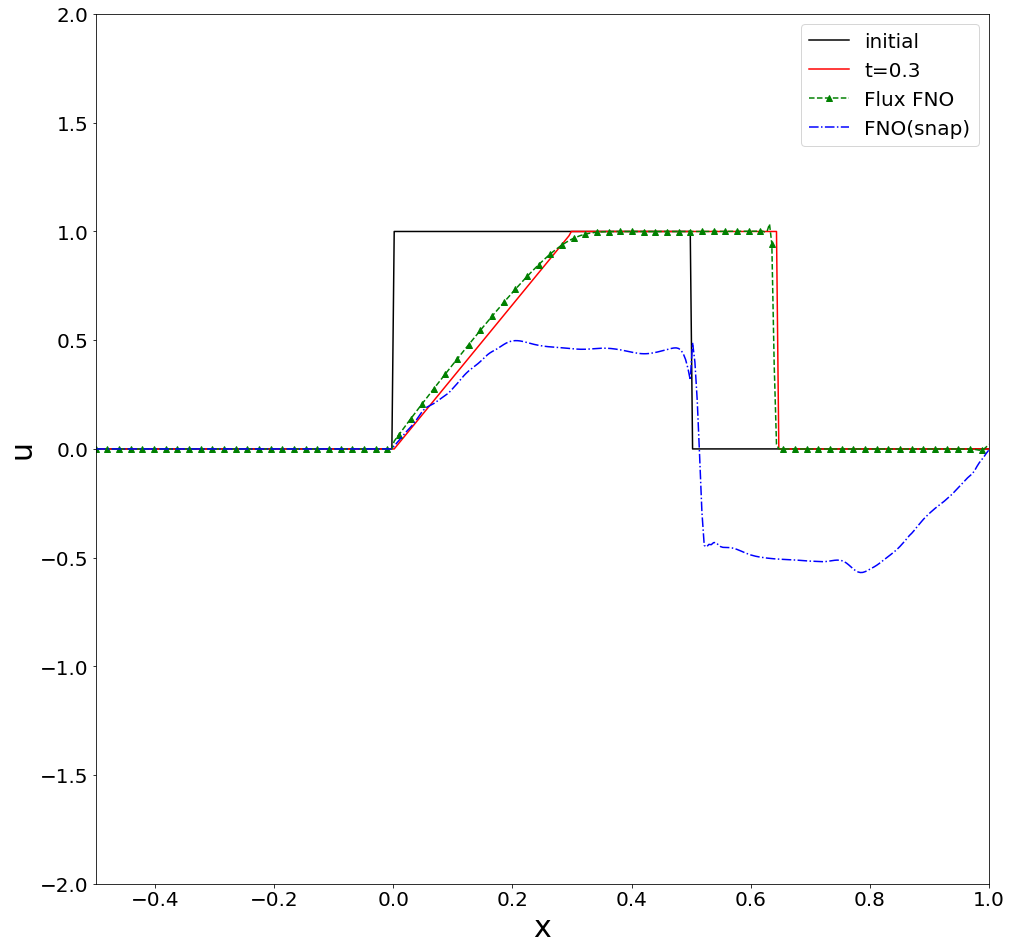

In [ ]:
plt.figure(figsize=(16, 16))

plt.xlim([-0.5, 1])
plt.ylim([-2, 2])
plt.xlabel("x", fontsize=30)
plt.ylabel("u", fontsize=30)
# plt.plot(np.linspace(0,1,256),x_test[NN][0][0].detach().cpu(), 'black', label='initial')
plt.plot(
    np.linspace(-0.5, 1, 384),
    np.concatenate((np.zeros(128), A)),
    "black",
    label="initial",
)
plt.plot(
    np.linspace(-0.5, 1, 384), np.concatenate((np.zeros(128), A3)), "r", label="t=0.3"
)
plt.plot(
    np.linspace(-0.5, 1, 384),
    np.concatenate((np.zeros(128), xx2[3840 * 2].detach().cpu()[0].squeeze())),
    "--g^",
    label="Flux FNO",
    markevery=5,
)
plt.plot(
    np.linspace(-0.5, 1, 384),
    np.concatenate(
        (
            np.zeros(128),
            Reg_snap_model(torch.tensor(A).float().view(1, 256, 1).cuda())
            .squeeze()
            .detach()
            .cpu(),
        )
    ),
    "-.b",
    label="FNO(snap)",
)
# plt.plot(np.linspace(0,1,256),xx2[204].detach().cpu()[0], '--g^', markevery = 5)
# plt.plot(np.linspace(0,1,256),x_test[NN][0][127].detach().cpu(), 'blue', label='t=2.5')
# plt.plot(np.linspace(0,1,256),xx2[639].detach().cpu()[0], '--b^', markevery = 5)
# plt.plot(np.linspace(0,1,256),x_test[NN][0][255].detach().cpu(), 'y', label='t=5.0')
# plt.plot(np.linspace(0,1,256),xx2[256*5-1].detach().cpu()[0], '--y^', markevery = 5)
plt.tick_params(axis="both", which="major", labelsize=20)
plt.legend(loc="upper right", fontsize=20)

plt.savefig("Flux_FNO_OOD_STEP_Burgers_03_3.png")

In [ ]:
A6 = np.zeros(256)
A6[0:128] = 1

for t in range(1, int(15360) + 1):
    A6[0 : 127 + int((0.5 * (t / 25600)) * 256)] = 1
    A6[0 : int((256) * (t / 25600))] = (25600 / t) * np.linspace(0, 1, 256)[
        0 : int((256) * (t / 25600))
    ]

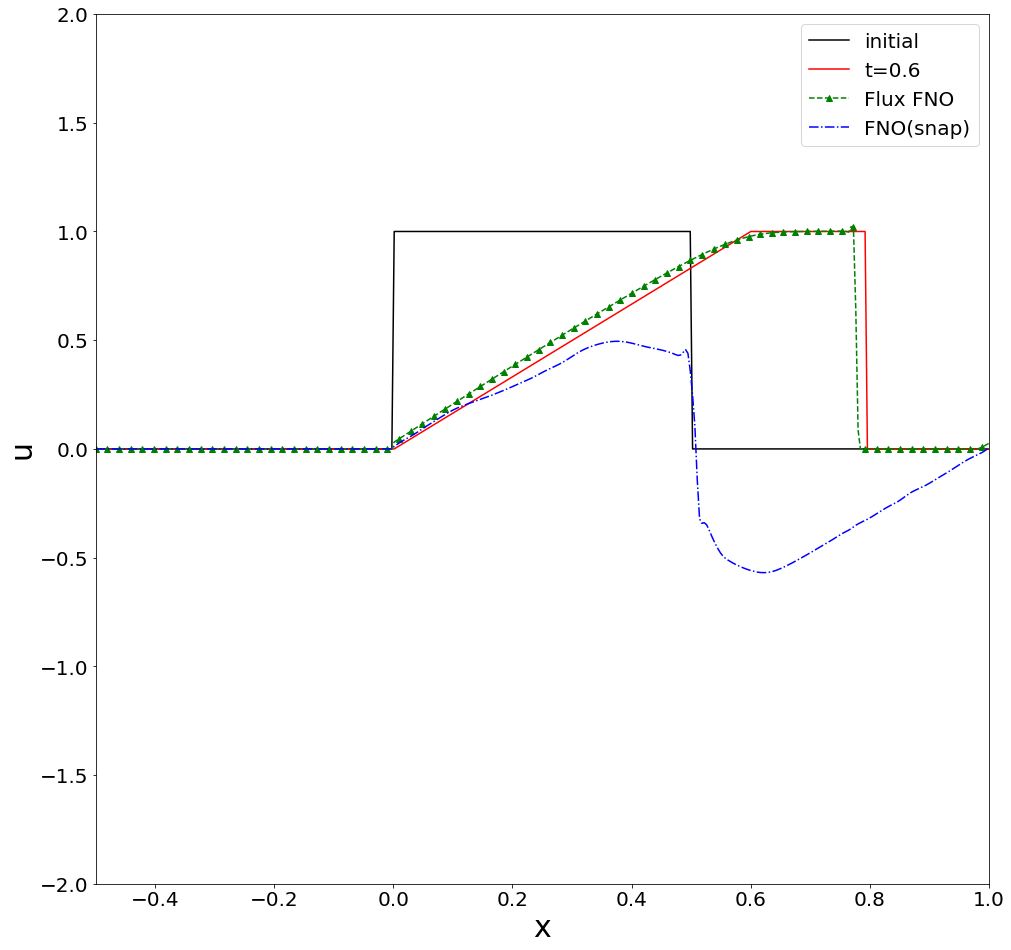

In [ ]:
plt.figure(figsize=(16, 16))

plt.xlim([-0.5, 1])
plt.ylim([-2, 2])
plt.xlabel("x", fontsize=30)
plt.ylabel("u", fontsize=30)
# plt.plot(np.linspace(0,1,256),x_test[NN][0][0].detach().cpu(), 'black', label='initial')
plt.plot(
    np.linspace(-0.5, 1, 384),
    np.concatenate((np.zeros(128), A)),
    "black",
    label="initial",
)
plt.plot(
    np.linspace(-0.5, 1, 384), np.concatenate((np.zeros(128), A6)), "r", label="t=0.6"
)
plt.plot(
    np.linspace(-0.5, 1, 384),
    np.concatenate((np.zeros(128), xx2[3840 * 4].detach().cpu()[0].squeeze())),
    "--g^",
    label="Flux FNO",
    markevery=5,
)
plt.plot(
    np.linspace(-0.5, 1, 384),
    np.concatenate(
        (
            np.zeros(128),
            Reg_snap_model(
                Reg_snap_model(torch.tensor(A).float().view(1, 256, 1).cuda())
            )
            .squeeze()
            .detach()
            .cpu(),
        )
    ),
    "-.b",
    label="FNO(snap)",
)
# plt.plot(np.linspace(0,1,256),xx2[204].detach().cpu()[0], '--g^', markevery = 5)
# plt.plot(np.linspace(0,1,256),x_test[NN][0][127].detach().cpu(), 'blue', label='t=2.5')
# plt.plot(np.linspace(0,1,256),xx2[639].detach().cpu()[0], '--b^', markevery = 5)
# plt.plot(np.linspace(0,1,256),x_test[NN][0][255].detach().cpu(), 'y', label='t=5.0')
# plt.plot(np.linspace(0,1,256),xx2[256*5-1].detach().cpu()[0], '--y^', markevery = 5)
plt.tick_params(axis="both", which="major", labelsize=20)
plt.legend(loc="upper right", fontsize=20)

plt.savefig("Flux_FNO_OOD_STEP_Burgers_06_3.png")

# ===

In [ ]:
for datas in ["TEST_1_0.1_512_uniform"]:
    with open("./data/" + datas + ".pickle", "rb") as fr:
        train_raw_set_loaded = pickle.load(fr)

    x_test = []

    for i in range(len(train_raw_set_loaded["train_X"])):
        x_test.append(
            (
                torch.tensor(
                    train_raw_set_loaded["train_X"][i][0], dtype=torch.float
                ).unsqueeze(-1),
                torch.tensor(train_raw_set_loaded["train_X"][i][1], dtype=torch.float),
            )
        )


In [ ]:
Flux_model.eval()

NN = 0
with torch.no_grad():
    x0 = x_test[NN][0][0].unsqueeze(0).cuda()
    f1 = Flux_model(torch.cat((torch.roll(x0.cuda(), 1, dims=1), x0.cuda()), dim=2))[0]
    f0 = Flux_model(torch.cat((x0.cuda(), torch.roll(x0.cuda(), -1, dims=1)), dim=2))[0]
    t1 = (
        torch.roll(x_test2[NN][1].cuda(), -1, dims=0)
        .unsqueeze(-1)
        .unsqueeze(-1)[0]
        .unsqueeze(0)
    )

    xx2 = [x0]
    T = 0
    for i in range(17536 * 2):
        T += t1
        x0 = x0 - t1 / (1 / 512) * (f0 - f1)
        f1 = Flux_model(
            torch.cat((torch.roll(x0.cuda(), 1, dims=1), x0.cuda()), dim=2)
        )[0]
        f0 = Flux_model(
            torch.cat((x0.cuda(), torch.roll(x0.cuda(), -1, dims=1)), dim=2)
        )[0]
        t1 = (
            torch.roll(x_test[NN][1].cuda(), -(i + 2), dims=0)
            .unsqueeze(-1)
            .unsqueeze(-1)[0]
            .unsqueeze(0)
        )
        if i % 1 == 0:
            xx2.append(x0)

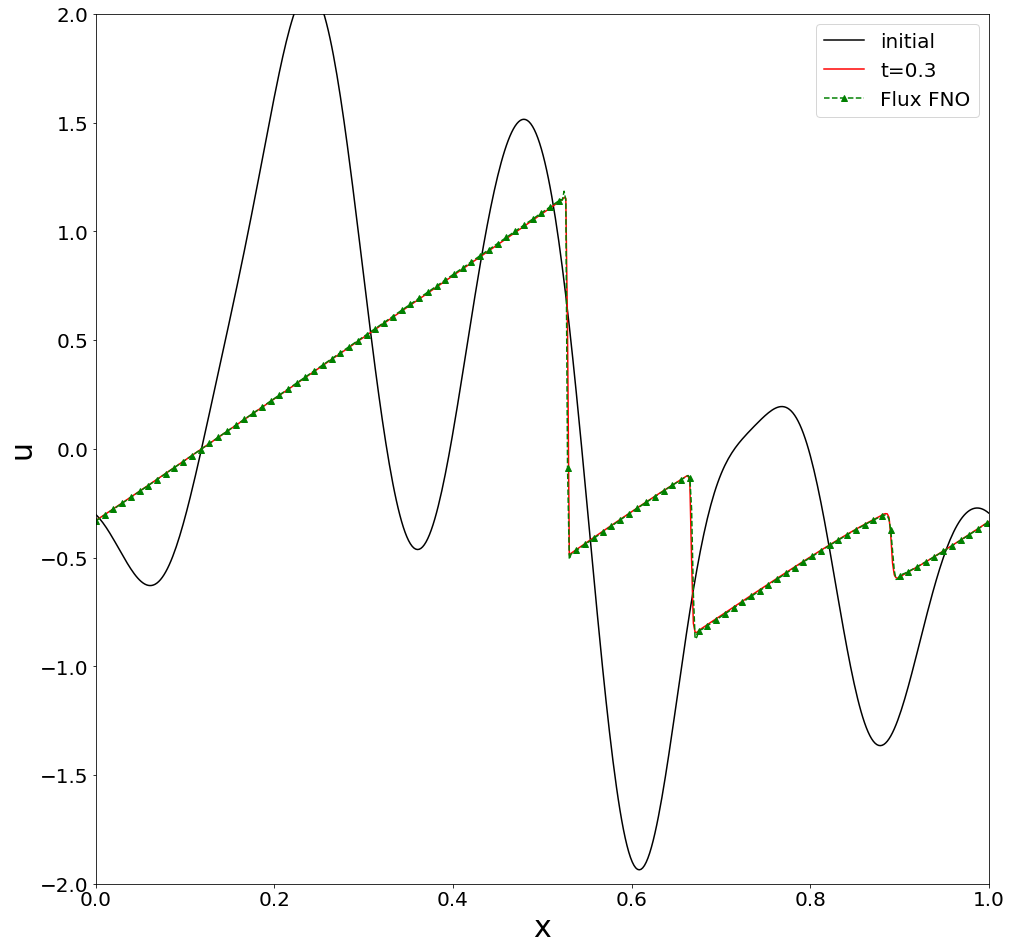

In [ ]:
plt.figure(figsize=(16, 16))

plt.xlim([0, 1])
plt.ylim([-2, 2])
plt.xlabel("x", fontsize=30)
plt.ylabel("u", fontsize=30)
# plt.plot(np.linspace(0,1,256),x_test[NN][0][0].detach().cpu(), 'black', label='initial')
plt.plot(
    np.linspace(0, 1, 512), x_test[0][0][0].detach().cpu(), "black", label="initial"
)
plt.plot(
    np.linspace(0, 1, 512), x_test[0][0][3840 * 4].detach().cpu(), "r", label="t=0.3"
)
plt.plot(
    np.linspace(0, 1, 512),
    xx2[3840 * 4].detach().cpu()[0],
    "--g^",
    label="Flux FNO",
    markevery=5,
)
# plt.plot(np.linspace(0,1,256),xx2[204].detach().cpu()[0], '--g^', markevery = 5)
# plt.plot(np.linspace(0,1,256),x_test[NN][0][127].detach().cpu(), 'blue', label='t=2.5')
# plt.plot(np.linspace(0,1,256),xx2[639].detach().cpu()[0], '--b^', markevery = 5)
# plt.plot(np.linspace(0,1,256),x_test[NN][0][255].detach().cpu(), 'y', label='t=5.0')
# plt.plot(np.linspace(0,1,256),xx2[256*5-1].detach().cpu()[0], '--y^', markevery = 5)
plt.tick_params(axis="both", which="major", labelsize=20)
plt.legend(loc="upper right", fontsize=20)

plt.savefig("Flux_FNO_OOD_512_Burgers_03_2.png")

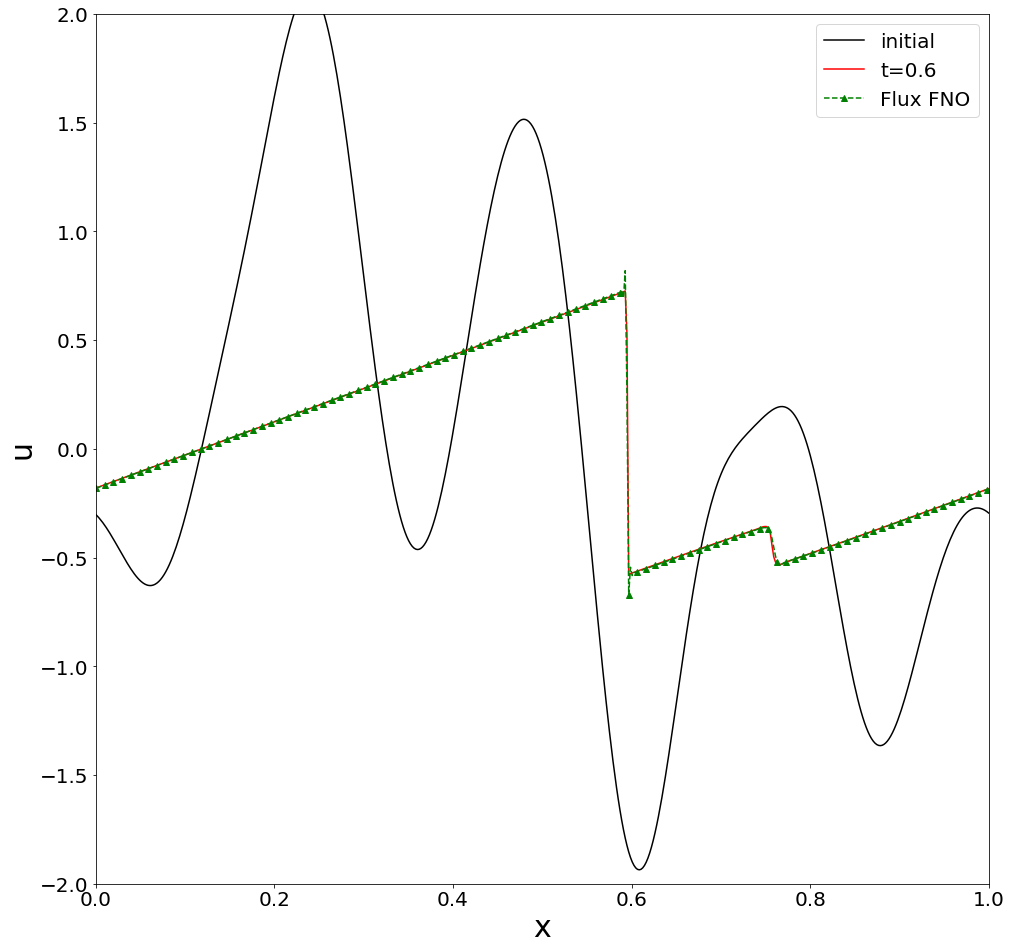

In [ ]:
plt.figure(figsize=(16, 16))

plt.xlim([0, 1])
plt.ylim([-2, 2])
plt.xlabel("x", fontsize=30)
plt.ylabel("u", fontsize=30)
# plt.plot(np.linspace(0,1,256),x_test[NN][0][0].detach().cpu(), 'black', label='initial')
plt.plot(
    np.linspace(0, 1, 512), x_test[0][0][0].detach().cpu(), "black", label="initial"
)
plt.plot(
    np.linspace(0, 1, 512), x_test[0][0][3840 * 8].detach().cpu(), "r", label="t=0.6"
)
plt.plot(
    np.linspace(0, 1, 512),
    xx2[3840 * 8].detach().cpu()[0],
    "--g^",
    label="Flux FNO",
    markevery=5,
)
# plt.plot(np.linspace(0,1,256),xx2[204].detach().cpu()[0], '--g^', markevery = 5)
# plt.plot(np.linspace(0,1,256),x_test[NN][0][127].detach().cpu(), 'blue', label='t=2.5')
# plt.plot(np.linspace(0,1,256),xx2[639].detach().cpu()[0], '--b^', markevery = 5)
# plt.plot(np.linspace(0,1,256),x_test[NN][0][255].detach().cpu(), 'y', label='t=5.0')
# plt.plot(np.linspace(0,1,256),xx2[256*5-1].detach().cpu()[0], '--y^', markevery = 5)
plt.tick_params(axis="both", which="major", labelsize=20)
plt.legend(loc="upper right", fontsize=20)

plt.savefig("Flux_FNO_OOD_512_Burgers_06_2.png")

In [ ]:
for datas in ["TEST_1_0.1_128_uniform"]:
    with open("./data/" + datas + ".pickle", "rb") as fr:
        train_raw_set_loaded = pickle.load(fr)

    x_test = []

    for i in range(len(train_raw_set_loaded["train_X"])):
        x_test.append(
            (
                torch.tensor(
                    train_raw_set_loaded["train_X"][i][0], dtype=torch.float
                ).unsqueeze(-1),
                torch.tensor(train_raw_set_loaded["train_X"][i][1], dtype=torch.float),
            )
        )


In [ ]:
Flux_model.eval()

NN = 0
with torch.no_grad():
    x0 = x_test[NN][0][0].unsqueeze(0).cuda()
    f1 = Flux_model(torch.cat((torch.roll(x0.cuda(), 1, dims=1), x0.cuda()), dim=2))[0]
    f0 = Flux_model(torch.cat((x0.cuda(), torch.roll(x0.cuda(), -1, dims=1)), dim=2))[0]
    t1 = (
        torch.roll(x_test2[NN][1].cuda(), -1, dims=0)
        .unsqueeze(-1)
        .unsqueeze(-1)[0]
        .unsqueeze(0)
    )

    xx2 = [x0]
    T = 0
    for i in range(17536 * 2):
        T += t1
        x0 = x0 - t1 / (1 / 128) * (f0 - f1)
        f1 = Flux_model(
            torch.cat((torch.roll(x0.cuda(), 1, dims=1), x0.cuda()), dim=2)
        )[0]
        f0 = Flux_model(
            torch.cat((x0.cuda(), torch.roll(x0.cuda(), -1, dims=1)), dim=2)
        )[0]
        t1 = (
            torch.roll(x_test[NN][1].cuda(), -(i + 2), dims=0)
            .unsqueeze(-1)
            .unsqueeze(-1)[0]
            .unsqueeze(0)
        )
        if i % 1 == 0:
            xx2.append(x0)

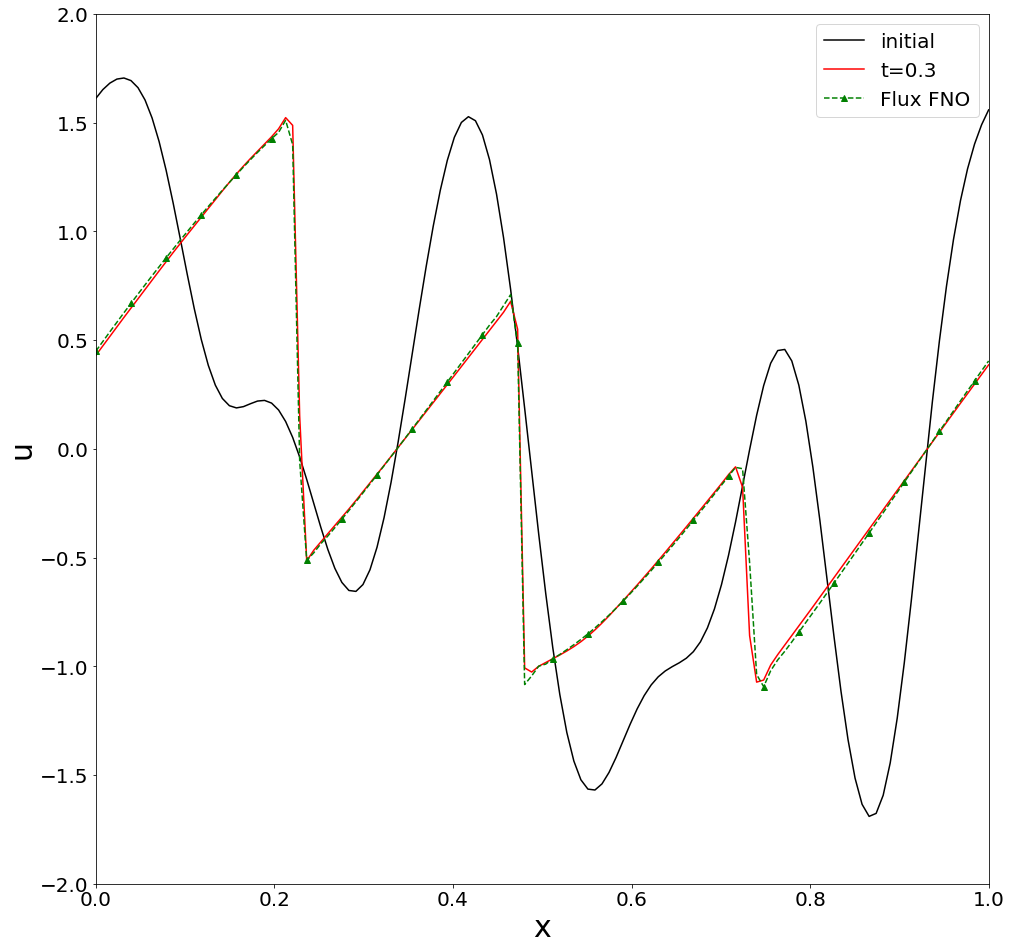

In [ ]:
plt.figure(figsize=(16, 16))

plt.xlim([0, 1])
plt.ylim([-2, 2])
plt.xlabel("x", fontsize=30)
plt.ylabel("u", fontsize=30)
# plt.plot(np.linspace(0,1,256),x_test[NN][0][0].detach().cpu(), 'black', label='initial')
plt.plot(
    np.linspace(0, 1, 128), x_test[0][0][0].detach().cpu(), "black", label="initial"
)
plt.plot(np.linspace(0, 1, 128), x_test[0][0][1920].detach().cpu(), "r", label="t=0.3")
plt.plot(
    np.linspace(0, 1, 128),
    xx2[1920].detach().cpu()[0],
    "--g^",
    label="Flux FNO",
    markevery=5,
)
# plt.plot(np.linspace(0,1,256),xx2[204].detach().cpu()[0], '--g^', markevery = 5)
# plt.plot(np.linspace(0,1,256),x_test[NN][0][127].detach().cpu(), 'blue', label='t=2.5')
# plt.plot(np.linspace(0,1,256),xx2[639].detach().cpu()[0], '--b^', markevery = 5)
# plt.plot(np.linspace(0,1,256),x_test[NN][0][255].detach().cpu(), 'y', label='t=5.0')
# plt.plot(np.linspace(0,1,256),xx2[256*5-1].detach().cpu()[0], '--y^', markevery = 5)
plt.tick_params(axis="both", which="major", labelsize=20)
plt.legend(loc="upper right", fontsize=20)

plt.savefig("Flux_FNO_OOD_128_Burgers_03_2.png")

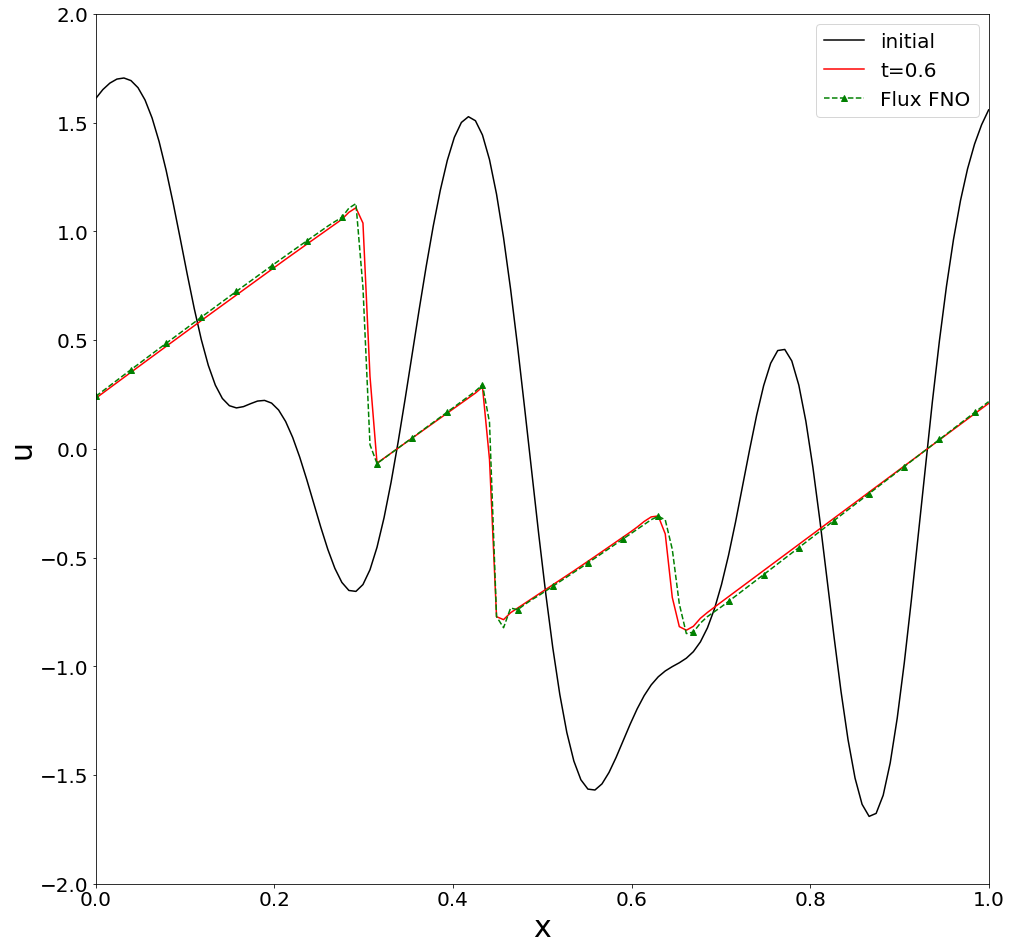

In [ ]:
plt.figure(figsize=(16, 16))

plt.xlim([0, 1])
plt.ylim([-2, 2])
plt.xlabel("x", fontsize=30)
plt.ylabel("u", fontsize=30)
# plt.plot(np.linspace(0,1,256),x_test[NN][0][0].detach().cpu(), 'black', label='initial')
plt.plot(
    np.linspace(0, 1, 128), x_test[0][0][0].detach().cpu(), "black", label="initial"
)
plt.plot(
    np.linspace(0, 1, 128), x_test[0][0][1920 * 2].detach().cpu(), "r", label="t=0.6"
)
plt.plot(
    np.linspace(0, 1, 128),
    xx2[1920 * 2].detach().cpu()[0],
    "--g^",
    label="Flux FNO",
    markevery=5,
)
# plt.plot(np.linspace(0,1,256),xx2[204].detach().cpu()[0], '--g^', markevery = 5)
# plt.plot(np.linspace(0,1,256),x_test[NN][0][127].detach().cpu(), 'blue', label='t=2.5')
# plt.plot(np.linspace(0,1,256),xx2[639].detach().cpu()[0], '--b^', markevery = 5)
# plt.plot(np.linspace(0,1,256),x_test[NN][0][255].detach().cpu(), 'y', label='t=5.0')
# plt.plot(np.linspace(0,1,256),xx2[256*5-1].detach().cpu()[0], '--y^', markevery = 5)
plt.tick_params(axis="both", which="major", labelsize=20)
plt.legend(loc="upper right", fontsize=20)

plt.savefig("Flux_FNO_OOD_128_Burgers_06_2.png")

# ===

In [ ]:
re = 3

model = FNO1d(5, 64, 1, 1).cuda()

print(count_params(model))

################################################################
# training and evaluation
################################################################
optimizer = Adam(model.parameters(), lr=learning_rate, weight_decay=re * 1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=step_size, gamma=gamma)

myloss = LpLoss(size_average=False)
myloss2 = LpLoss(size_average=False)
for ep in range(epochs):
    model.train()
    t1 = default_timer()
    train_mse = 0
    train_l2 = 0
    train_l2_2 = 0

    for x, t in train_loader:
        l2 = 0

        optimizer.zero_grad()

        f0 = model(torch.cat((x.cuda(), torch.roll(x.cuda(), -1, dims=1)), dim=2))
        f1 = model(torch.cat((torch.roll(x.cuda(), 1, dims=1), x.cuda()), dim=2))

        l2 += myloss(
            (
                x.cuda()
                - (
                    torch.roll(t.cuda(), -1, dims=0).unsqueeze(-1).unsqueeze(-1)
                    / (1 / 256)
                )
                * (f0 - f1)
            )[:-1],
            torch.roll(x.cuda(), -1, dims=0)[:-1],
        )

        F = model(torch.cat((x.cuda(), x.cuda()), dim=2))

        train_l2_2 += l2.item() / (
            len(train_loader) * x.cuda().shape[0] * x.cuda().shape[1]
        )

        # l2 += myloss(F, 0.5*(x.cuda())**2) #Burgers
        # l2 += myloss(F, x[0].cuda()) #advection

        l2.backward()  # use the l2 relative loss

        optimizer.step()

        train_l2 += l2.item() / (
            len(train_loader) * x.cuda().shape[0] * x.cuda().shape[1]
        )

    scheduler.step()
    model.eval()

    print(ep, train_l2 - train_l2_2, train_l2)

    t2 = default_timer()

53633
0 0.0 1.2159229479852668e-06
1 0.0 1.0104302220354022e-06
2 0.0 9.464611192159178e-07
3 0.0 8.607364461568074e-07
4 0.0 7.948298333710564e-07
5 0.0 7.373987242126045e-07
6 0.0 6.934164496813447e-07
7 0.0 6.622686653731523e-07
8 0.0 6.447309217133135e-07
9 0.0 6.290614925618625e-07
10 0.0 6.172476782443196e-07
11 0.0 6.101248743442208e-07
12 0.0 6.057566077192622e-07
13 0.0 6.012232264717894e-07
14 0.0 5.977952039421849e-07
15 0.0 5.923444686902114e-07
16 0.0 5.957211894718452e-07
17 0.0 5.920293819336187e-07
18 0.0 5.894246926465321e-07
19 0.0 5.923700588554261e-07
20 0.0 5.910116436481124e-07
21 0.0 5.891856440030097e-07
22 0.0 5.901827123939014e-07
23 0.0 5.890171769590923e-07
24 0.0 5.89825285212436e-07
25 0.0 5.899555377302593e-07
26 0.0 5.874336398655459e-07
27 0.0 5.878787784049083e-07
28 0.0 5.892816006723336e-07
29 0.0 5.880764060987676e-07
30 0.0 5.890112068922662e-07
31 0.0 5.888248463538494e-07
32 0.0 5.889760181353753e-07
33 0.0 5.856238186233419e-07
34 0.0 5.90892982

In [ ]:
with open("Flux_Burgers_5_64_1_1_woconsis.pickle", "wb") as fw:
    pickle.dump(model, fw)

In [ ]:
class FNO1dwoFr(nn.Module):
    def __init__(self, modes, width, depth, kernz):
        super(FNO1dwoFr, self).__init__()

        """
        The overall network. It contains 4 layers of the Fourier layer.
        1. Lift the input to the desire channel dimension by self.fc0 .
        2. 4 layers of the integral operators u' = (W + K)(u).
            W defined by self.w; K defined by self.conv .
        3. Project from the channel space to the output space by self.fc1 and self.fc2 .
        
        input: the solution of the initial condition and location (a(x), x)
        input shape: (batchsize, x=s, c=2)
        output: the solution of a later timestep
        output shape: (batchsize, x=s, c=1)
        """

        self.modes1 = modes
        self.width = width
        self.depth = depth
        self.kernelsize = kernz
        self.padding = 2  # pad the domain if input is non-periodic
        self.fc0 = nn.Linear(3, self.width, bias=False)  # input channel is 2: (a(x), x)

        self.fouriers = nn.ModuleList(
            [
                SpectralConv1d(self.width, self.width, self.modes1)
                for i in range(self.depth)
            ]
        )
        self.convs = nn.ModuleList(
            [
                nn.Conv1d(
                    self.width,
                    self.width,
                    self.kernelsize,
                    padding=int(self.kernelsize / 2),
                )
                for i in range(self.depth)
            ]
        )

        self.relu = nn.GELU()

        self.fc1 = nn.Linear(self.width, 128, bias=False)
        self.fc2 = nn.Linear(128, 1)

    def forward(self, x):
        grid = self.get_grid(x.shape, x.device)
        x = torch.cat((x, grid), dim=-1)
        # print(x.shape)
        x = self.fc0(x)
        # print(x.shape)
        x = x.permute(0, 2, 1)
        # print(x.shape)
        # x = F.pad(x, [0,self.padding]) # pad the domain if input is non-periodic

        x0 = x

        for i in range(self.depth):
            x1 = self.fouriers[i](x)
            x2 = self.convs[i](x)

            x = self.relu(x2)
            # x0 = x
            # x = self.relu(x1)

        # x = x[..., :-self.padding] # pad the domain if input is non-periodic
        x = x.permute(0, 2, 1)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)

        return x

    def get_grid(self, shape, device):
        batchsize, size_x = shape[0], shape[1]
        gridx = torch.tensor(np.linspace(0, 1, size_x), dtype=torch.float)
        gridx = gridx.reshape(1, size_x, 1).repeat([batchsize, 1, 1])
        return gridx.to(device)

In [ ]:
re = 3

model = FNO1dwoFr(5, 64, 1, 1).cuda()

print(count_params(model))

################################################################
# training and evaluation
################################################################
optimizer = Adam(model.parameters(), lr=learning_rate, weight_decay=re * 1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=step_size, gamma=gamma)

myloss = LpLoss(size_average=False)
myloss2 = LpLoss(size_average=False)
for ep in range(epochs):
    model.train()
    t1 = default_timer()
    train_mse = 0
    train_l2 = 0
    train_l2_2 = 0

    for x, t in train_loader:
        l2 = 0

        optimizer.zero_grad()

        f0 = model(torch.cat((x.cuda(), torch.roll(x.cuda(), -1, dims=1)), dim=2))
        f1 = model(torch.cat((torch.roll(x.cuda(), 1, dims=1), x.cuda()), dim=2))

        l2 += myloss(
            (
                x.cuda()
                - (
                    torch.roll(t.cuda(), -1, dims=0).unsqueeze(-1).unsqueeze(-1)
                    / (1 / 256)
                )
                * (f0 - f1)
            )[:-1],
            torch.roll(x.cuda(), -1, dims=0)[:-1],
        )

        F = model(torch.cat((x.cuda(), x.cuda()), dim=2))

        train_l2_2 += l2.item() / (
            len(train_loader) * x.cuda().shape[0] * x.cuda().shape[1]
        )

        l2 += myloss(F, 0.5 * (x.cuda()) ** 2)  # Burgers
        # l2 += myloss(F, x[0].cuda()) #advection

        l2.backward()  # use the l2 relative loss

        optimizer.step()

        train_l2 += l2.item() / (
            len(train_loader) * x.cuda().shape[0] * x.cuda().shape[1]
        )

    scheduler.step()
    model.eval()

    print(ep, train_l2 - train_l2_2, train_l2)

    t2 = default_timer()

In [ ]:
with open("Flux_Burgers_5_64_1_1_wofr.pickle", "wb") as fw:
    pickle.dump(model, fw)

In [ ]:
class FNO1dwoCNN(nn.Module):
    def __init__(self, modes, width, depth, kernz):
        super(FNO1dwoCNN, self).__init__()

        """
        The overall network. It contains 4 layers of the Fourier layer.
        1. Lift the input to the desire channel dimension by self.fc0 .
        2. 4 layers of the integral operators u' = (W + K)(u).
            W defined by self.w; K defined by self.conv .
        3. Project from the channel space to the output space by self.fc1 and self.fc2 .
        
        input: the solution of the initial condition and location (a(x), x)
        input shape: (batchsize, x=s, c=2)
        output: the solution of a later timestep
        output shape: (batchsize, x=s, c=1)
        """

        self.modes1 = modes
        self.width = width
        self.depth = depth
        self.kernelsize = kernz
        self.padding = 2  # pad the domain if input is non-periodic
        self.fc0 = nn.Linear(3, self.width, bias=False)  # input channel is 2: (a(x), x)

        self.fouriers = nn.ModuleList(
            [
                SpectralConv1d(self.width, self.width, self.modes1)
                for i in range(self.depth)
            ]
        )
        self.convs = nn.ModuleList(
            [
                nn.Conv1d(
                    self.width,
                    self.width,
                    self.kernelsize,
                    padding=int(self.kernelsize / 2),
                )
                for i in range(self.depth)
            ]
        )

        self.relu = nn.GELU()

        self.fc1 = nn.Linear(self.width, 128, bias=False)
        self.fc2 = nn.Linear(128, 1)

    def forward(self, x):
        grid = self.get_grid(x.shape, x.device)
        x = torch.cat((x, grid), dim=-1)
        # print(x.shape)
        x = self.fc0(x)
        # print(x.shape)
        x = x.permute(0, 2, 1)
        # print(x.shape)
        # x = F.pad(x, [0,self.padding]) # pad the domain if input is non-periodic

        x0 = x

        for i in range(self.depth):
            x1 = self.fouriers[i](x)
            x2 = self.convs[i](x)

            x = self.relu(x1)
            # x0 = x
            # x = self.relu(x1)

        # x = x[..., :-self.padding] # pad the domain if input is non-periodic
        x = x.permute(0, 2, 1)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)

        return x

    def get_grid(self, shape, device):
        batchsize, size_x = shape[0], shape[1]
        gridx = torch.tensor(np.linspace(0, 1, size_x), dtype=torch.float)
        gridx = gridx.reshape(1, size_x, 1).repeat([batchsize, 1, 1])
        return gridx.to(device)

In [ ]:
re = 3

model = FNO1dwoCNN(5, 64, 1, 1).cuda()

print(count_params(model))

################################################################
# training and evaluation
################################################################
optimizer = Adam(model.parameters(), lr=learning_rate, weight_decay=re * 1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=step_size, gamma=gamma)

myloss = LpLoss(size_average=False)
myloss2 = LpLoss(size_average=False)
for ep in range(epochs):
    model.train()
    t1 = default_timer()
    train_mse = 0
    train_l2 = 0
    train_l2_2 = 0

    for x, t in train_loader:
        l2 = 0

        optimizer.zero_grad()

        f0 = model(torch.cat((x.cuda(), torch.roll(x.cuda(), -1, dims=1)), dim=2))
        f1 = model(torch.cat((torch.roll(x.cuda(), 1, dims=1), x.cuda()), dim=2))

        l2 += myloss(
            (
                x.cuda()
                - (
                    torch.roll(t.cuda(), -1, dims=0).unsqueeze(-1).unsqueeze(-1)
                    / (1 / 256)
                )
                * (f0 - f1)
            )[:-1],
            torch.roll(x.cuda(), -1, dims=0)[:-1],
        )

        F = model(torch.cat((x.cuda(), x.cuda()), dim=2))

        train_l2_2 += l2.item() / (
            len(train_loader) * x.cuda().shape[0] * x.cuda().shape[1]
        )

        l2 += myloss(F, 0.5 * (x.cuda()) ** 2)  # Burgers
        # l2 += myloss(F, x[0].cuda()) #advection

        l2.backward()  # use the l2 relative loss

        optimizer.step()

        train_l2 += l2.item() / (
            len(train_loader) * x.cuda().shape[0] * x.cuda().shape[1]
        )

    scheduler.step()
    model.eval()

    print(ep, train_l2 - train_l2_2, train_l2)

    t2 = default_timer()

In [ ]:
with open("Flux_Burgers_5_64_1_1_wofr.pickle", "wb") as fw:
    pickle.dump(model, fw)

PicklingError: Can't pickle <class '__main__.FNO1d'>: it's not the same object as __main__.FNO1d

# ===

In [ ]:
"""
with open(file='Flux_Burgers_5_64_1_1_wofr_2.pickle', mode='rb') as f:
    modelwofr = pickle.load(f)
    """

with open(file="Flux_Burgers_5_64_1_1_woconsis.pickle", mode="rb") as f:
    modelwoconsis = pickle.load(f)

"""
with open(file='Flux_Burgers_5_64_1_1_wocnn.pickle', mode='rb') as f:
    modelwocnn = pickle.load(f)
    """

with open(file="Flux_Burgers_5_64_1_1_w100.pickle", mode="rb") as f:
    Flux_model = pickle.load(f)

In [ ]:
for datas in ["TEST_1_0.03_256_uniform"]:
    with open("./data/" + datas + ".pickle", "rb") as fr:
        train_raw_set_loaded = pickle.load(fr)

    x_test = []

    for i in range(len(train_raw_set_loaded["train_X"])):
        x_test.append(
            (
                torch.tensor(
                    train_raw_set_loaded["train_X"][i][0], dtype=torch.float
                ).unsqueeze(-1),
                torch.tensor(train_raw_set_loaded["train_X"][i][1], dtype=torch.float),
            )
        )


In [ ]:
relnorms3 = []
relnorms6 = []
infnorms3 = []
infnorms6 = []

for model in [Flux_model, modelwoconsis]:
    model.eval()

    NN = 0
    with torch.no_grad():
        x0 = x_test[NN][0][0].unsqueeze(0).cuda()
        f1 = model(torch.cat((torch.roll(x0.cuda(), 1, dims=1), x0.cuda()), dim=2))[0]
        f0 = model(torch.cat((x0.cuda(), torch.roll(x0.cuda(), -1, dims=1)), dim=2))[0]
        t1 = (
            torch.roll(x_test[NN][1].cuda(), -1, dims=0)
            .unsqueeze(-1)
            .unsqueeze(-1)[0]
            .unsqueeze(0)
        )

        xx2 = [x0]
        T = 0
        for i in range(int(17536)):
            T += t1
            x0 = x0 - t1 / (1 / 256) * (f0 - f1)
            f1 = model(torch.cat((torch.roll(x0.cuda(), 1, dims=1), x0.cuda()), dim=2))[
                0
            ]
            f0 = model(
                torch.cat((x0.cuda(), torch.roll(x0.cuda(), -1, dims=1)), dim=2)
            )[0]
            t1 = (
                torch.roll(x_test[NN][1].cuda(), -(i + 2), dims=0)
                .unsqueeze(-1)
                .unsqueeze(-1)[0]
                .unsqueeze(0)
            )
            if i % 1 == 0:
                xx2.append(x0)

        relnorms3.append(
            torch.norm(x_test[NN][0][3840 * 2] - xx2[3840 * 2].cpu())
            / torch.norm(x_test[NN][0][3840 * 2])
        )
        relnorms6.append(
            torch.norm(x_test[NN][0][3840 * 4] - xx2[3840 * 4].cpu())
            / torch.norm(x_test[NN][0][3840 * 4])
        )
        infnorms3.append(torch.max(x_test[NN][0][3840 * 2] - xx2[3840 * 2].cpu()))
        infnorms6.append(torch.max(x_test[NN][0][3840 * 4] - xx2[3840 * 4].cpu()))

In [112]:
relnorms3t = torch.tensor(relnorms3)

In [113]:
infnorms3t = torch.tensor(infnorms3)

In [114]:
relnorms6t = torch.tensor(relnorms6)

In [115]:
infnorms6t = torch.tensor(infnorms6)

In [116]:
relnorms3t

tensor([0.1281, 0.0949])

In [117]:
infnorms3t

tensor([0.3968, 0.2964])

In [118]:
relnorms6t

tensor([0.1411, 0.2118])

In [119]:
infnorms6t

tensor([0.2999, 0.4311])

In [ ]:
relnorms3 = []
relnorms6 = []
infnorms3 = []
infnorms6 = []

A6 = np.zeros(256)
A6[0:128] = 1
A3 = torch.tensor(A3).view(1, 256, 1)
for t in range(1, int(15360) + 1):
    A6[0 : 127 + int((0.5 * (t / 25600)) * 256)] = 1
    A6[0 : int((256) * (t / 25600))] = (25600 / t) * np.linspace(0, 1, 256)[
        0 : int((256) * (t / 25600))
    ]

A6 = torch.tensor(A6).view(1, 256, 1)

for model in [Flux_model, modelwoconsis]:
    model.eval()

    A = np.zeros(256)
    A[0:128] = 1

    NN = 0
    with torch.no_grad():
        x0 = torch.tensor(A).view(1, 256, 1).float().cuda()
        f1 = model(torch.cat((torch.roll(x0.cuda(), 1, dims=1), x0.cuda()), dim=2))[0]
        f0 = model(torch.cat((x0.cuda(), torch.roll(x0.cuda(), -1, dims=1)), dim=2))[0]
        t1 = (
            torch.roll(x_test2[NN][1].cuda(), -1, dims=0)
            .unsqueeze(-1)
            .unsqueeze(-1)[0]
            .unsqueeze(0)
        )

        xx2 = [x0]
        T = 0
        for i in range(int(17536 * 1)):
            T += t1
            x0 = x0 - t1 / (1 / 256) * (f0 - f1)
            f1 = model(torch.cat((torch.roll(x0.cuda(), 1, dims=1), x0.cuda()), dim=2))[
                0
            ]
            f0 = model(
                torch.cat((x0.cuda(), torch.roll(x0.cuda(), -1, dims=1)), dim=2)
            )[0]
            t1 = (
                torch.roll(x_test[NN][1].cuda(), -(i + 2), dims=0)
                .unsqueeze(-1)
                .unsqueeze(-1)[0]
                .unsqueeze(0)
            )
            if i % 1 == 0:
                xx2.append(x0)

        relnorms3.append(
            torch.norm(A3 - xx2[3840 * 2].cpu()) / torch.norm(x_test[NN][0][3840 * 2])
        )
        relnorms6.append(
            torch.norm(A6 - xx2[3840 * 4].cpu()) / torch.norm(x_test[NN][0][3840 * 4])
        )
        infnorms3.append(torch.max(A3 - xx2[3840 * 2].cpu()))
        infnorms6.append(torch.max(A6 - xx2[3840 * 4].cpu()))


C:\Users\Public\Documents\ESTsoft\CreatorTemp/ipykernel_59488/700894517.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  A3 = torch.tensor(A3).view(1,256,1)


In [132]:
relnorms3

[tensor(0.0814, dtype=torch.float64), tensor(0.3758, dtype=torch.float64)]

In [133]:
infnorms3

[tensor(0.2152, dtype=torch.float64), tensor(0.1985, dtype=torch.float64)]

In [134]:
relnorms6

[tensor(0.1465, dtype=torch.float64), tensor(0.7124, dtype=torch.float64)]

In [135]:
infnorms6

[tensor(0.6070, dtype=torch.float64), tensor(0.1688, dtype=torch.float64)]

# ===

In [ ]:
re = 3

model = FNO1d(5, 64, 1, 1).cuda()

print(count_params(model))

################################################################
# training and evaluation
################################################################
optimizer = Adam(model.parameters(), lr=learning_rate, weight_decay=re * 1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=step_size, gamma=gamma)

myloss = LpLoss(size_average=False)
myloss2 = LpLoss(size_average=False)
for ep in range(epochs):
    model.train()
    t1 = default_timer()
    train_mse = 0
    train_l2 = 0
    train_l2_2 = 0

    for x, t in train_loader:
        l2 = 0

        optimizer.zero_grad()

        f0 = model(torch.cat((x.cuda(), torch.roll(x.cuda(), -1, dims=1)), dim=2))
        f1 = model(torch.cat((torch.roll(x.cuda(), 1, dims=1), x.cuda()), dim=2))
        xtmp = x.cuda() - 0.5 * (
            torch.roll(t.cuda(), -1, dims=0).unsqueeze(-1).unsqueeze(-1) / (1 / 256)
        ) * (f0 - f1)
        f00 = model(
            torch.cat((xtmp.cuda(), torch.roll(xtmp.cuda(), -1, dims=1)), dim=2)
        )
        f11 = model(torch.cat((torch.roll(xtmp.cuda(), 1, dims=1), xtmp.cuda()), dim=2))

        xout = x.cuda() - (
            torch.roll(t.cuda(), -1, dims=0).unsqueeze(-1).unsqueeze(-1) / (1 / 256)
        ) * (f00 - f11)

        l2 += myloss(xout[:-1], torch.roll(x.cuda(), -1, dims=0)[:-1])

        F = model(torch.cat((x.cuda(), x.cuda()), dim=2))

        train_l2_2 += l2.item() / (len(train_loader) * x.cuda().shape[0])

        l2 += myloss(F, 0.5 * (x.cuda()) ** 2)  # Burgers
        # l2 += myloss(F, x[0].cuda()) #advection

        l2.backward()  # use the l2 relative loss

        optimizer.step()

        train_l2 += l2.item() / (len(train_loader) * x.cuda().shape[0])

    scheduler.step()
    model.eval()

    print(ep, train_l2 - train_l2_2, train_l2_2)

    t2 = default_timer()

53633
0 0.07515309444323516 0.0007136793134758546
1 0.04254302452901676 0.0007525378120082775
2 0.03834380831649091 0.0007521083554816676
3 0.03471853113338032 0.0007505394647106235
4 0.03131643230520116 0.0007471267713025506
5 0.028992348766015672 0.0007422014649736849
6 0.028015100360535502 0.0007381928584379106
7 0.023381355928817744 0.0007346690272893997
8 0.021061662478651284 0.0007250557114572361
9 0.01931322188195344 0.000721680827533802
10 0.01635411645946596 0.0007152073924080473
11 0.017020472156643682 0.000710659677775479
12 0.015514537295317382 0.0006982800869461106
13 0.014419100247965328 0.0006770864252053136
14 0.014814795790975402 0.0005973046386222308
15 0.012285064457782473 0.000461378575239858
16 0.011506523859720858 0.00043252705705756504
17 0.011610772996603232 0.0004282087087125739
18 0.011502954487325811 0.00042196217044042226
19 0.011425959674852873 0.0004171933565919879
20 0.011310456943151382 0.00041175370193607366
21 0.010766701661344415 0.0004058747767029625

In [165]:
t

tensor([3.9062e-05, 3.9062e-05, 3.9062e-05, 3.9062e-05, 3.9062e-05, 3.9062e-05,
        3.9062e-05, 3.9062e-05, 3.9062e-05, 3.9062e-05, 3.9062e-05, 3.9062e-05,
        3.9062e-05, 3.9062e-05, 3.9062e-05, 3.9062e-05, 3.9062e-05, 3.9062e-05,
        3.9062e-05, 3.9062e-05, 3.9062e-05, 3.9062e-05, 3.9062e-05, 3.9062e-05,
        3.9062e-05, 3.9062e-05, 3.9062e-05, 3.9062e-05, 3.9062e-05, 3.9062e-05,
        3.9062e-05, 3.9062e-05, 3.9062e-05, 3.9062e-05, 3.9062e-05, 3.9062e-05,
        3.9062e-05, 3.9062e-05, 3.9062e-05, 3.9062e-05, 3.9062e-05, 3.9062e-05,
        3.9062e-05, 3.9062e-05, 3.9062e-05, 3.9062e-05, 3.9062e-05, 3.9062e-05,
        3.9062e-05, 3.9062e-05, 3.9062e-05, 3.9062e-05, 3.9062e-05, 3.9062e-05,
        3.9062e-05, 3.9062e-05, 3.9062e-05, 3.9062e-05, 3.9062e-05, 3.9062e-05,
        3.9062e-05, 3.9062e-05, 3.9062e-05, 3.9062e-05, 3.9062e-05, 3.9062e-05,
        3.9062e-05, 3.9062e-05, 3.9062e-05, 3.9062e-05, 3.9062e-05, 3.9062e-05,
        3.9062e-05, 3.9062e-05, 3.9062e-

In [ ]:
with open("Flux_Burgers_RK2_5_64_1_1.pickle", "wb") as fw:
    pickle.dump(model, fw)

In [ ]:
with open(file="Flux_Burgers_RK2_5_64_1_1.pickle", mode="rb") as f:
    model = pickle.load(f)


In [ ]:
lnorm = torch.zeros(4, 5, 2).cuda()


TN = 10

for NN in range(TN):
    model.eval()

    with torch.no_grad():
        x0 = x_test[NN][0][0].unsqueeze(0).cuda()
        t1 = (
            torch.roll(x_test2[NN][1].cuda(), -1, dims=0)
            .unsqueeze(-1)
            .unsqueeze(-1)[0]
            .unsqueeze(0)
        )

        xx = [x0]
        T = 0
        for i in range(17536):
            T += t1
            f1 = model(torch.cat((torch.roll(x0.cuda(), 1, dims=1), x0.cuda()), dim=2))[
                0
            ]
            f0 = model(
                torch.cat((x0.cuda(), torch.roll(x0.cuda(), -1, dims=1)), dim=2)
            )[0]
            xtmp = x0 - 0.5 * t1 / (1 / 256) * (f0 - f1)
            f11 = model(
                torch.cat((torch.roll(xtmp.cuda(), 1, dims=1), xtmp.cuda()), dim=2)
            )[0]
            f00 = model(
                torch.cat((xtmp.cuda(), torch.roll(xtmp.cuda(), -1, dims=1)), dim=2)
            )[0]
            x0 = x0 - t1 / (1 / 256) * (f00 - f11)
            t1 = (
                torch.roll(x_test[NN][1].cuda(), -(i + 2), dims=0)
                .unsqueeze(-1)
                .unsqueeze(-1)[0]
                .unsqueeze(0)
            )
            if i % 1 == 0:
                xx.append(x0)

    for i in range(4):
        lnorm[0][i][0] += (
            torch.norm(x_test[NN][0][3840 * (i + 1)].cuda() - xx[3840 * (i + 1)].cuda())
            / torch.norm(x_test[NN][0][3840 * (i + 1)].cuda())
            / TN
        )

    xx11 = xx[0]

    for i in range(1, 15361):
        xx11 = torch.cat((xx11, xx[i]))

    lnorm[0][4][0] += (
        torch.norm(x_test[NN][0].cuda() - xx11.cuda())
        / torch.norm(x_test[0][0].cuda())
        / TN
    )

    for i in range(4):
        lnorm[0][i][1] += (
            torch.max(x_test[NN][0][3840 * (i + 1)].cuda() - xx[3840 * (i + 1)].cuda())
            / TN
        )

    lnorm[0][4][1] += torch.max(x_test[NN][0].cuda() - xx11.cuda()) / TN

    print(NN)

0
1
2
3
4
5
6
7
8
9


In [ ]:
t

tensor([3.9062e-05, 3.9062e-05, 3.9062e-05, 3.9062e-05, 3.9062e-05, 3.9062e-05,
        3.9062e-05, 3.9062e-05, 3.9062e-05, 3.9062e-05, 3.9062e-05, 3.9062e-05,
        3.9062e-05, 3.9062e-05, 3.9062e-05, 3.9062e-05, 3.9062e-05, 3.9062e-05,
        3.9062e-05, 3.9062e-05, 3.9062e-05, 3.9062e-05, 3.9062e-05, 3.9062e-05,
        3.9062e-05, 3.9062e-05, 3.9062e-05, 3.9062e-05, 3.9062e-05, 3.9062e-05,
        3.9062e-05, 3.9062e-05, 3.9062e-05, 3.9062e-05, 3.9062e-05, 3.9062e-05,
        3.9062e-05, 3.9062e-05, 3.9062e-05, 3.9062e-05, 3.9062e-05, 3.9062e-05,
        3.9062e-05, 3.9062e-05, 3.9062e-05, 3.9062e-05, 3.9062e-05, 3.9062e-05,
        3.9062e-05, 3.9062e-05, 3.9062e-05, 3.9062e-05, 3.9062e-05, 3.9062e-05,
        3.9062e-05, 3.9062e-05, 3.9062e-05, 3.9062e-05, 3.9062e-05, 3.9062e-05,
        3.9062e-05, 3.9062e-05, 3.9062e-05, 3.9062e-05, 3.9062e-05, 3.9062e-05,
        3.9062e-05, 3.9062e-05, 3.9062e-05, 3.9062e-05, 3.9062e-05, 3.9062e-05,
        3.9062e-05, 3.9062e-05, 3.9062e-

In [ ]:
lnorm

tensor([[[0.0460, 0.2903],
         [0.0431, 0.2082],
         [0.0423, 0.1325],
         [0.0411, 0.1009],
         [0.0374, 0.4627]],

        [[0.0000, 0.0000],
         [0.0000, 0.0000],
         [0.0000, 0.0000],
         [0.0000, 0.0000],
         [0.0000, 0.0000]],

        [[0.0000, 0.0000],
         [0.0000, 0.0000],
         [0.0000, 0.0000],
         [0.0000, 0.0000],
         [0.0000, 0.0000]],

        [[0.0000, 0.0000],
         [0.0000, 0.0000],
         [0.0000, 0.0000],
         [0.0000, 0.0000],
         [0.0000, 0.0000]]], device='cuda:0')

In [ ]:
model.eval()
NN = 0
with torch.no_grad():
    x0 = x_test[NN][0][0].unsqueeze(0).cuda()
    t1 = (
        torch.roll(x_test[NN][1].cuda(), -1, dims=0)
        .unsqueeze(-1)
        .unsqueeze(-1)[0]
        .unsqueeze(0)
    )

    xx3 = [x0]
    T = 0
    for i in range(80000):
        T += t1

        f1 = model(torch.cat((torch.roll(x0.cuda(), 1, dims=1), x0.cuda()), dim=2))[0]
        f0 = model(torch.cat((x0.cuda(), torch.roll(x0.cuda(), -1, dims=1)), dim=2))[0]
        a = f0
        xtmp = (x0 - 0.5 * t1 / (1 / 256) * (f0 - f1)).clone()
        f11 = model(
            torch.cat((torch.roll(xtmp.cuda(), 1, dims=1), xtmp.cuda()), dim=2)
        )[0]
        f00 = model(
            torch.cat((xtmp.cuda(), torch.roll(xtmp.cuda(), -1, dims=1)), dim=2)
        )[0]
        x0 = (x0 - t1 / (1 / 256) * (f00 - f11)).clone()
        b = f00
        t1 = (
            torch.roll(x_test[NN][1].cuda(), -(i + 2), dims=0)
            .unsqueeze(-1)
            .unsqueeze(-1)[0]
            .unsqueeze(0)
        )

        if i % 1 == 0:
            xx3.append(x0)

In [168]:
t1

tensor([[[3.9062e-05]]], device='cuda:0')

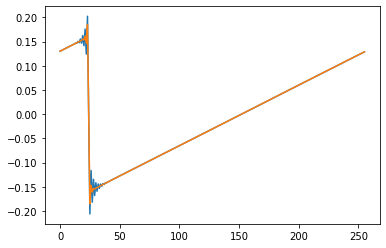

In [ ]:
N = 79400
plt.plot(xx[N].squeeze().detach().cpu())
plt.plot(xx3[N].squeeze().detach().cpu())
# plt.plot(x_test[NN][0][N])

# ===

In [242]:
del weno

In [ ]:
def weno(x):
    eps = 1e-6

    beta1l = (13 / 12) * (
        torch.roll(x.cuda(), 2, dims=1) - 2 * torch.roll(x.cuda(), 1, dims=1) + x.cuda()
    ) ** 2 + (1 / 4) * (
        torch.roll(x.cuda(), 2, dims=1)
        - 4 * torch.roll(x.cuda(), 1, dims=1)
        + 3 * x.cuda()
    ) ** 2
    beta2l = (13 / 12) * (
        torch.roll(x.cuda(), 1, dims=1)
        - 2 * x.cuda()
        + torch.roll(x.cuda(), -1, dims=1)
    ) ** 2 + (1 / 4) * (
        torch.roll(x.cuda(), 1, dims=1) - torch.roll(x.cuda(), -1, dims=1)
    ) ** 2
    beta3l = (13 / 12) * (
        x.cuda()
        - 2 * torch.roll(x.cuda(), -1, dims=1)
        + torch.roll(x.cuda(), -2, dims=1)
    ) ** 2 + (1 / 4) * (
        3 * x.cuda()
        - 4 * torch.roll(x.cuda(), -1, dims=1)
        + torch.roll(x.cuda(), -2, dims=1)
    ) ** 2

    alpha1l = (1 / 10) / (eps + beta1l) ** 2
    alpha2l = (3 / 5) / (eps + beta2l) ** 2
    alpha3l = (3 / 10) / (eps + beta3l) ** 2

    weight1l = alpha1l / (alpha1l + alpha2l + alpha3l)
    weight2l = alpha2l / (alpha1l + alpha2l + alpha3l)
    weight3l = alpha3l / (alpha1l + alpha2l + alpha3l)

    u1l = (
        (1 / 3) * torch.roll(x.cuda(), 2, dims=1)
        - (7 / 6) * torch.roll(x.cuda(), 1, dims=1)
        + (11 / 6) * x.cuda()
    )
    u2l = (
        -(1 / 6) * torch.roll(x.cuda(), 1, dims=1)
        + (5 / 6) * x.cuda()
        + (1 / 3) * torch.roll(x.cuda(), -1, dims=1)
    )
    u3l = (
        (1 / 3) * x.cuda()
        + (5 / 6) * torch.roll(x.cuda(), -1, dims=1)
        - (1 / 6) * torch.roll(x.cuda(), -2, dims=1)
    )

    xl = weight1l * u1l + weight2l * u2l + weight3l * u3l

    beta1 = (13 / 12) * (
        torch.roll(x.cuda(), 1, dims=1)
        - 2 * torch.roll(x.cuda(), 0, dims=1)
        + torch.roll(x.cuda(), -1, dims=1)
    ) ** 2 + (1 / 4) * (
        torch.roll(x.cuda(), 1, dims=1)
        - 4 * torch.roll(x.cuda(), 0, dims=1)
        + 3 * torch.roll(x.cuda(), -1, dims=1)
    ) ** 2
    beta2 = (13 / 12) * (
        torch.roll(x.cuda(), 0, dims=1)
        - 2 * torch.roll(x.cuda(), -1, dims=1)
        + torch.roll(x.cuda(), -2, dims=1)
    ) ** 2 + (1 / 4) * (
        torch.roll(x.cuda(), 0, dims=1) - torch.roll(x.cuda(), -2, dims=1)
    ) ** 2
    beta3 = (13 / 12) * (
        torch.roll(x.cuda(), -1, dims=1)
        - 2 * torch.roll(x.cuda(), -2, dims=1)
        + torch.roll(x.cuda(), -3, dims=1)
    ) ** 2 + (1 / 4) * (
        3 * torch.roll(x.cuda(), -1, dims=1)
        - 4 * torch.roll(x.cuda(), -2, dims=1)
        + torch.roll(x.cuda(), -3, dims=1)
    ) ** 2

    alpha1 = (1 / 10) / (eps + beta1) ** 2
    alpha2 = (3 / 5) / (eps + beta2) ** 2
    alpha3 = (3 / 10) / (eps + beta3) ** 2

    weight1 = alpha1 / (alpha1 + alpha2 + alpha3)
    weight2 = alpha2 / (alpha1 + alpha2 + alpha3)
    weight3 = alpha3 / (alpha1 + alpha2 + alpha3)

    u1 = (
        (1 / 3) * torch.roll(x.cuda(), 1, dims=1)
        - (7 / 6) * torch.roll(x.cuda(), 0, dims=1)
        + (11 / 6) * torch.roll(x.cuda(), -1, dims=1)
    )
    u2 = (
        -(1 / 6) * torch.roll(x.cuda(), 0, dims=1)
        + (5 / 6) * torch.roll(x.cuda(), -1, dims=1)
        + (1 / 3) * torch.roll(x.cuda(), -2, dims=1)
    )
    u3 = (
        (1 / 3) * torch.roll(x.cuda(), -1, dims=1)
        + (5 / 6) * torch.roll(x.cuda(), -2, dims=1)
        - (1 / 6) * torch.roll(x.cuda(), -3, dims=1)
    )

    xr = weight1l * u1 + weight2l * u2 + weight3l * u3

    return xl, xr

In [ ]:
re = 3

model = FNO1d(5, 64, 1, 1).cuda()

print(count_params(model))

################################################################
# training and evaluation
################################################################
optimizer = Adam(model.parameters(), lr=learning_rate, weight_decay=re * 1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=step_size, gamma=gamma)

myloss = LpLoss(size_average=False)
myloss2 = LpLoss(size_average=False)
for ep in range(epochs):
    model.train()
    t1 = default_timer()
    train_mse = 0
    train_l2 = 0
    train_l2_2 = 0

    for x, t in train_loader:
        l2 = 0

        optimizer.zero_grad()

        (xl, xr) = weno(x.cuda())
        f0 = model(torch.cat((xl, xr), dim=2))
        (xl2, xr2) = weno(torch.roll(x.cuda(), 1, dims=1))
        f1 = model(torch.cat((xl2, xr2), dim=2))

        x = x.cuda() - (
            torch.roll(t.cuda(), -1, dims=0).unsqueeze(-1).unsqueeze(-1) / (1 / 256)
        ) * (f0 - f1)

        l2 += myloss(x[:-1], torch.roll(x.cuda(), -1, dims=0)[:-1])

        F = model(torch.cat((x.cuda(), x.cuda()), dim=2))

        train_l2_2 += l2.item() / (len(train_loader) * x.cuda().shape[0])

        l2 += myloss(F, 0.5 * (x.cuda()) ** 2)  # Burgers
        # l2 += myloss(F, x[0].cuda()) #advection

        l2.backward()  # use the l2 relative loss

        optimizer.step()

        train_l2 += l2.item() / (len(train_loader) * x.cuda().shape[0])

    scheduler.step()
    model.eval()

    print(ep, train_l2 - train_l2_2, train_l2_2)

    t2 = default_timer()

53633
0 0.07013878026286038 0.000834076106597326
1 0.04090728382383924 0.0008344014238958292
2 0.03262985605538184 0.0008344480800442394
3 0.02926533844919974 0.0008345151185793319
4 0.026195309106922252 0.0008345228785795995
5 0.023839505358157972 0.0008345342939229391
6 0.01955915129679796 0.0008345435890614205
7 0.01781684670631626 0.0008345455319963795
8 0.016092897131328315 0.0008345812656426507
9 0.017222780396034434 0.0008345754515673777
10 0.015209468246168001 0.0008346238129674211
11 0.014822187456351348 0.0008346641766593643
12 0.013187788182992108 0.0008346935294715589
13 0.012938326947096918 0.0008347268156511222


KeyboardInterrupt: 

In [ ]:
with open("Flux_Burgers_WENO_5_64_1_1.pickle", "wb") as fw:
    pickle.dump(model, fw)

In [ ]:
with open(file="Flux_Burgers_5_64_1_1.pickle", mode="rb") as f:
    model = pickle.load(f)


In [ ]:
lnorm = torch.zeros(4, 5, 2).cuda()


TN = 10

for NN in range(TN):
    model.eval()

    with torch.no_grad():
        x0 = x_test[NN][0][0].unsqueeze(0).cuda()
        (xl, xr) = weno(x0)
        f0 = model(torch.cat((xl, xr), dim=2))
        (xl2, xr2) = weno(torch.roll(x0.cuda(), 1, dims=1))
        f1 = model(torch.cat((xl2, xr2), dim=2))
        t1 = (
            torch.roll(x_test2[NN][1].cuda(), -1, dims=0)
            .unsqueeze(-1)
            .unsqueeze(-1)[0]
            .unsqueeze(0)
        )

        xx = [x0]
        T = 0
        for i in range(17536):
            T += t1

            x0 = x0 - t1 / (1 / 256) * (f0 - f1)

            (xl, xr) = weno(x0)
            f0 = model(torch.cat((xl, xr), dim=2))
            (xl2, xr2) = weno(torch.roll(x0.cuda(), 1, dims=1))
            f1 = model(torch.cat((xl2, xr2), dim=2))

            t1 = (
                torch.roll(x_test[NN][1].cuda(), -(i + 2), dims=0)
                .unsqueeze(-1)
                .unsqueeze(-1)[0]
                .unsqueeze(0)
            )
            if i % 1 == 0:
                xx.append(x0)

    for i in range(4):
        lnorm[0][i][0] += (
            torch.norm(x_test[NN][0][3840 * (i + 1)].cuda() - xx[3840 * (i + 1)].cuda())
            / torch.norm(x_test[NN][0][3840 * (i + 1)].cuda())
            / TN
        )

    xx11 = xx[0]

    for i in range(1, 15361):
        xx11 = torch.cat((xx11, xx[i]))

    lnorm[0][4][0] += (
        torch.norm(x_test[NN][0].cuda() - xx11.cuda())
        / torch.norm(x_test[0][0].cuda())
        / TN
    )

    for i in range(4):
        lnorm[0][i][1] += (
            torch.max(x_test[NN][0][3840 * (i + 1)].cuda() - xx[3840 * (i + 1)].cuda())
            / TN
        )

    lnorm[0][4][1] += torch.max(x_test[NN][0].cuda() - xx11.cuda()) / TN

    print(NN)

0
1
2
3
4
5
6
7
8
9


In [9]:
lnorm

tensor([[[0.1255, 0.1933],
         [0.2313, 0.2681],
         [0.4612, 0.3339],
         [0.6427, 0.2985],
         [0.2263, 1.0584]],

        [[0.0000, 0.0000],
         [0.0000, 0.0000],
         [0.0000, 0.0000],
         [0.0000, 0.0000],
         [0.0000, 0.0000]],

        [[0.0000, 0.0000],
         [0.0000, 0.0000],
         [0.0000, 0.0000],
         [0.0000, 0.0000],
         [0.0000, 0.0000]],

        [[0.0000, 0.0000],
         [0.0000, 0.0000],
         [0.0000, 0.0000],
         [0.0000, 0.0000],
         [0.0000, 0.0000]]], device='cuda:0')

In [ ]:
model.eval()


with torch.no_grad():
    NN = 0

    x0 = x_test[NN][0][0].unsqueeze(0).cuda()
    (xl, xr) = weno(x0)
    f0 = model(torch.cat((xl, xr), dim=2))
    (xl2, xr2) = weno(torch.roll(x0.cuda(), 1, dims=1))
    f1 = model(torch.cat((xl2, xr2), dim=2))
    t1 = (
        torch.roll(x_test2[NN][1].cuda(), -1, dims=0)
        .unsqueeze(-1)
        .unsqueeze(-1)[0]
        .unsqueeze(0)
    )

    xx = [x0]
    T = 0
    for i in range(19000):
        T += t1

        x0 = x0 - t1 / (1 / 256) * (f0 - f1)

        (xl, xr) = weno(x0)
        f0 = model(torch.cat((xl, xr), dim=2))
        (xl2, xr2) = weno(torch.roll(x0.cuda(), 1, dims=1))
        f1 = model(torch.cat((xl2, xr2), dim=2))

        t1 = (
            torch.roll(x_test[NN][1].cuda(), -(i + 2), dims=0)
            .unsqueeze(-1)
            .unsqueeze(-1)[0]
            .unsqueeze(0)
        )
        if i % 1 == 0:
            xx.append(x0)

In [103]:
M = 10000

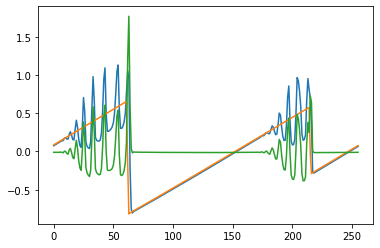

In [ ]:
# plt.plot(xr.squeeze().detach().cpu())
plt.plot(xx[M].squeeze().detach().cpu())
plt.plot(x_test[NN][0][M])
plt.plot((xx[M] - x_test[NN][0][M].cuda()).squeeze().detach().cpu())


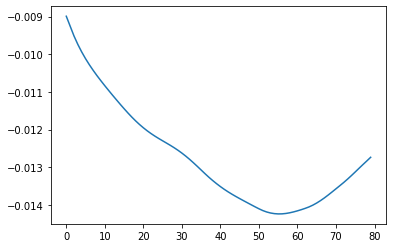

In [ ]:
plt.plot((xx[M] - x_test[NN][0][M].cuda())[0][70:150].squeeze().detach().cpu())

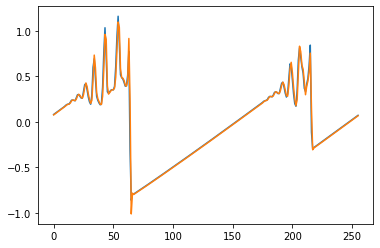

In [ ]:
plt.plot((weno(xx[9800])[0]).squeeze().detach().cpu())
# plt.plot((weno(xx[9800])[1]).squeeze().detach().cpu())
plt.plot(xx[9800].squeeze().detach().cpu())

In [276]:
torch.max(weno(xx[2900])[0])

tensor(6800.6162, device='cuda:0')

In [277]:
torch.max(xx[2900])

tensor(7103.6978, device='cuda:0')

In [ ]:
import numpy as np
import pyweno.weno


x = np.linspace(0.0, 2 * np.pi, 21)
f = (np.cos(x[1:]) - np.cos(x[:-1])) / (x[1] - x[0])
q = pyweno.weno.reconstruct(f, 5, "left")

ModuleNotFoundError: No module named 'pyweno'

In [73]:
import weno4

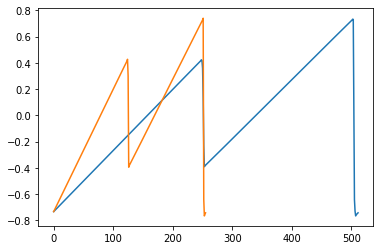

In [ ]:
plt.plot(
    weno4.weno4(
        np.linspace(0, 1, 512),
        np.linspace(0, 1, 256),
        x_test[NN][0][M].squeeze().detach().cpu(),
    )
)
plt.plot(weno(x_test[NN][0][M])[0].detach().cpu())

In [77]:
xx[2900].squeeze()

torch.Size([1, 256, 1])